# Carbon Emission Full Pipeline Notebook

This single Jupyter notebook combines both project scripts in the correct order:

1. **Preprocessing** from `preprocessing.py`
2. **Model training** from `model_training.py`

Run the notebook from top to bottom. The preprocessing section creates the model-ready arrays in `outputs/`, and the model-training section loads those arrays, trains models, evaluates them, visualizes results, and saves model artifacts in `outputs/models/`.

# Part 1: Data Preprocessing

This section loads `Carbon Emission.csv`, splits it into train/test **before** any statistic is computed, then fits a single `sklearn.pipeline.Pipeline` — missing-value imputation, winsorization, encoding, and feature pruning — **only on the training fold**. The fitted pipeline is applied unchanged to the test fold and to any new input at inference time.

**Why this matters:** the previous version of this notebook computed medians, winsorization bounds, encoder categories, and feature-importance rankings on the *full* dataset before splitting. That leaks test-set information into every preprocessing decision, which inflates every downstream metric. Splitting first and fitting only on `X_train` closes that leak.

## 1. Setup

We use `pandas` and `numpy` for data processing, `seaborn` and `matplotlib` for visual checks, and `scikit-learn` utilities for encoding, splitting, scaling, and pipeline assembly.

If your notebook kernel is missing packages, install them with:

```bash
pip install pandas numpy seaborn matplotlib scikit-learn joblib optuna xgboost lightgbm catboost
```

In [ ]:
%pip install pandas numpy seaborn matplotlib scikit-learn joblib optuna xgboost lightgbm catboost


In [ ]:
from importlib.util import find_spec

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "seaborn": "seaborn",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "optuna": "optuna",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "catboost": "catboost",
}
missing_packages = [pip_name for module_name, pip_name in required_packages.items() if find_spec(module_name) is None]

if missing_packages:
    raise ImportError(
        "Missing required packages: "
        + ", ".join(missing_packages)
        + ". Install them with: pip install "
        + " ".join(missing_packages)
    )

import json
import warnings
from ast import literal_eval
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Suppress noisy but harmless warnings; keep data-type and deprecation
# warnings from core libraries visible so we do not miss real issues.
warnings.filterwarnings("ignore", category=UserWarning)          # seaborn layout
warnings.filterwarnings("ignore", category=FutureWarning)        # pandas internals
warnings.filterwarnings("ignore", message=".*force_all_finite.*")# sklearn 1.6 rename
warnings.filterwarnings("ignore", message=".*n_features_in.*")   # sklearn estimator
# NOTE: RuntimeWarning and DeprecationWarning are intentionally NOT suppressed.

# DATA_PATH: adjust if your CSV lives elsewhere.
# The notebook expects it in the same folder as this .ipynb file.
DATA_PATH = Path("Carbon Emission.csv")

# Existence check — fail fast with a clear message before any cell
# tries to read the file.
if not DATA_PATH.exists():
    # Try common alternative spellings / locations
    _alternatives = [
        Path("Carbon_Emission.csv"),
        Path("data/Carbon Emission.csv"),
        Path("data/Carbon_Emission.csv"),
    ]
    _found = next((p for p in _alternatives if p.exists()), None)
    if _found:
        DATA_PATH = _found
        print(f"Note: using '{DATA_PATH}' (alternative spelling found)")
    else:
        raise FileNotFoundError(
            f"Dataset not found at '{DATA_PATH.resolve()}'.\n"
            f"Place 'Carbon Emission.csv' in the same folder as this "
            f"notebook and re-run this cell.\n"
            f"Tried alternatives: {[str(p) for p in _alternatives]}"
        )
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)  # global numpy seed — ensures reproducibility
                             # for any code using np.random directly
TEST_SIZE = 0.20
TARGET = "CarbonEmission"

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

# ── Unified logging ──────────────────────────────────────────
# report_lines is the single accumulator for the entire notebook.
# Defined ONCE here (Part 1 setup) and reused by Parts 2 and 3.
# Never redefine report_lines or log() in later setup cells.
report_lines = []

def log(message=""):
    """Append message to report_lines and print it."""
    print(message)
    report_lines.append(str(message))


## 2. Load and Audit

Plain audit of the raw file: shape, duplicates, missing values, summary statistics. **Nothing is imputed, clipped, or encoded here** — those steps all move into the pipeline below, fit only on the training fold, so this cell is purely descriptive and safe to run on the full raw data.

In [ ]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

log("STEP 1 - LOAD AND AUDIT (raw data, no transformations applied)")
log(f"Shape: {df.shape}")
log(f"Duplicates: {df.duplicated().sum()}")
log(f"Columns: {df.columns.tolist()}")

print("First rows")
display(df.head())

print("Column summary")
display(df.describe(include="all").T)

missing = (
    df.isna().sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)
print("Missing value summary (raw)")
display(missing)
log(f"Columns with missing values: {missing.index.tolist()}")


In [ ]:
if not missing.empty:
    missing_plot_df = missing.reset_index(names="column")
    ax = sns.barplot(data=missing_plot_df, x="missing_count", y="column", color="#4C78A8")
    ax.set_title("Missing Values by Column (raw data)")
    ax.set_xlabel("Missing rows")
    ax.set_ylabel("Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


## 3. Train/Test Split — Before Any Preprocessing

This is the key structural change from the previous version of this notebook. The split happens **now**, on the untouched raw data, before a single median, mode, winsorization bound, encoder category, or importance ranking is computed.

Everything that follows — imputation, outlier clipping, encoding, collinearity pruning, importance pruning — is a `Pipeline` fit **only on `X_train_raw`**. The test fold is only ever `.transform()`-ed, never `.fit()`-ed. This is what makes the reported test metrics in Part 2 trustworthy: no test-set statistic ever influences how the training data (or the test data itself) gets preprocessed.

In [ ]:
log("STEP 2 - TRAIN/TEST SPLIT (on raw, untouched data)")

df_train_raw, df_test_raw = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
)

X_train_raw = df_train_raw.drop(columns=[TARGET]).reset_index(drop=True)
y_train     = df_train_raw[TARGET].reset_index(drop=True)
X_test_raw  = df_test_raw.drop(columns=[TARGET]).reset_index(drop=True)
y_test      = df_test_raw[TARGET].reset_index(drop=True)

log(f"Train rows: {X_train_raw.shape[0]}   Test rows: {X_test_raw.shape[0]}")
log(f"Raw feature count (pre-pipeline): {X_train_raw.shape[1]}")
log("From this point on, every fit() call below sees X_train_raw ONLY. "
    "X_test_raw is only ever transformed with statistics learned from train.")

display(X_train_raw.head())


## 4. Target Exploration (training fold only)

`CarbonEmission` is the prediction target. We inspect its distribution, skewness, and outliers **on the training fold** — inspecting the test fold's target here would just be another form of peeking. The target is trained on its raw scale — no `np.log1p` transform is applied, since the tree-based models (CatBoost, LightGBM, XGBoost, Random Forest) handle skew natively.

In [ ]:
target_summary = y_train.describe().to_frame(TARGET)
target_summary.loc["skewness"] = y_train.skew()
target_summary.loc["kurtosis"] = y_train.kurt()
display(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y_train, kde=True, bins=40, ax=axes[0], color="#4C78A8")
axes[0].set_title("CarbonEmission Distribution (train)")
axes[0].set_xlabel("CarbonEmission")

sns.boxplot(x=y_train, ax=axes[1], color="#F58518")
axes[1].set_title("CarbonEmission Outlier View (train)")
axes[1].set_xlabel("CarbonEmission")

plt.tight_layout()
plt.show()


In [ ]:
y_log_preview = np.log1p(y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y_train, kde=True, bins=40, ax=axes[0], color="#4C78A8")
axes[0].set_title(f"Original Target (train), skew = {y_train.skew():.3f}")
axes[0].set_xlabel("CarbonEmission")

sns.histplot(y_log_preview, kde=True, bins=40, ax=axes[1], color="#54A24B")
axes[1].set_title(f"Log1p Target (train), skew = {pd.Series(y_log_preview).skew():.3f}")
axes[1].set_xlabel("log1p(CarbonEmission)")

plt.tight_layout()
plt.show()


## 5. Vehicle Type Missingness (training fold only)

`Vehicle Type` is missing exactly when a respondent doesn't own/use a vehicle — this is **structural** missingness (the value is meaningfully absent, not randomly lost), so it's filled with the sentinel category `"none"` rather than a median/mode. That fill is a fixed domain constant, not a statistic learned from data, so — unlike the numeric imputation below — it's applied identically to every row via a stateless pipeline step (`VehicleTypeFiller`, defined in Section 9).

In [ ]:
vehicle_null_transport = X_train_raw[X_train_raw["Vehicle Type"].isna()]["Transport"].value_counts()
vehicle_present_transport = X_train_raw[X_train_raw["Vehicle Type"].notna()]["Transport"].value_counts()

log("Vehicle Type null -> Transport breakdown (train)")
log(vehicle_null_transport.to_string())
log("Vehicle Type non-null -> Transport breakdown (train)")
log(vehicle_present_transport.to_string())

display(pd.DataFrame({
    "vehicle_type_missing": vehicle_null_transport,
    "vehicle_type_present": vehicle_present_transport
}).fillna(0).astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vehicle_null_transport.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Transport When Vehicle Type Is Missing (train)")
axes[0].set_xlabel("Transport")
axes[0].set_ylabel("Rows")

vehicle_present_transport.plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Transport When Vehicle Type Exists (train)")
axes[1].set_xlabel("Transport")
axes[1].set_ylabel("Rows")

plt.tight_layout()
plt.show()

log(f"Vehicle Type nulls in train: {X_train_raw['Vehicle Type'].isna().sum()} "
    f"({X_train_raw['Vehicle Type'].isna().mean()*100:.1f}%)")
log("Actual fill happens inside the pipeline (VehicleTypeFiller step, Section 9), "
    "applied identically to train, test, and inference-time inputs.")


## 6. Categorical Impact Checks (training fold only)

Median `CarbonEmission` by category, to sanity-check that the categorical predictors actually relate to the target. Computed on the training fold only, so this exploration can't be influenced by (or leak into) the held-out test set.

In [ ]:
categorical_checks = [
    "Frequency of Traveling by Air",
    "Waste Bag Size",
    "How Often Shower",
    "Vehicle Type",
    "Heating Energy Source",
    "Energy efficiency",
    "Transport",
    "Diet",
]

_train_view = X_train_raw.copy()
_train_view[TARGET] = y_train

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.ravel()

for ax, col in zip(axes, categorical_checks):
    order = _train_view.groupby(col)[TARGET].median().sort_values().index
    sns.barplot(data=_train_view, x=col, y=TARGET, estimator=np.median, errorbar=None, order=order, ax=ax)
    ax.set_title(f"Median CarbonEmission by {col} (train)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

del _train_view  # exploration-only view; not used by the pipeline below


## 7. Multi-Label Columns (preview, training fold only)

`Recycling` and `Cooking_With` are stringified lists (e.g. `"['Paper', 'Plastic']"`). Parsing them into binary flag columns is a **deterministic** operation on each row's raw value — it doesn't learn anything from the data distribution, so it's safe as a stateless pipeline step (`MultiLabelBinarizer`, Section 9) applied identically before or after the split. This cell just previews the result on the training fold.

In [ ]:
def _preview_parse(series):
    return series.apply(lambda value: literal_eval(value) if isinstance(value, str) else [])

RECYCLING_ITEMS = ["Paper", "Plastic", "Glass", "Metal"]
COOKING_ITEMS   = ["Stove", "Oven", "Microwave", "Grill", "Airfryer"]

_recycle_counts = _preview_parse(X_train_raw["Recycling"]).apply(len)
_cook_counts    = _preview_parse(X_train_raw["Cooking_With"]).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=_recycle_counts, ax=axes[0], color="#4C78A8")
axes[0].set_title("Number of Recycling Material Types (train)")
axes[0].set_xlabel("Recycling_Count")

sns.countplot(x=_cook_counts, ax=axes[1], color="#F58518")
axes[1].set_title("Number of Cooking Appliance Types (train)")
axes[1].set_xlabel("Cooking_Appliance_Count")

plt.tight_layout()
plt.show()

log(f"Recycling items tracked: {RECYCLING_ITEMS}")
log(f"Cooking items tracked: {COOKING_ITEMS}")
del _recycle_counts, _cook_counts


## 8. Feature Engineering

Four candidate interpretable features were evaluated during development:

- `Vehicle_Emission_Class`: broad low, medium, high vehicle-emission tier
- `Digital_Footprint`: combined daily TV/PC and internet hours
- `Lifestyle_Sustainability_Score`: higher values indicate more sustainable habits
- `Air_Vehicle_Interaction`: combined effect of frequent air travel and vehicle distance

All four were **dropped** from the final pipeline — the pruned tree-model pipeline achieves higher accuracy without them, so they are not added below.

In [ ]:
log("STEP 3 - FEATURE ENGINEERING")
log("Engineered features (Vehicle_Emission_Class, Digital_Footprint, "
    "Lifestyle_Sustainability_Score, Air_Vehicle_Interaction) were evaluated "
    "during development and SKIPPED — they did not improve tree-model accuracy.")
log("Feature engineering step skipped — no plots to show.")


## 9. Building the Preprocessing Pipeline

Every step below is a small `sklearn`-compatible transformer (`BaseEstimator` + `TransformerMixin`), so the whole thing chains into one `Pipeline` object that can be `.fit()` once on `X_train_raw` and reused — unchanged — to `.transform()` the test fold, and later, any brand-new user input at inference time.

Two kinds of steps:

- **Stateless** (`HardBoundsClipper`, `VehicleTypeFiller`, `MultiLabelBinarizer`): the same fixed rule applied to every row, regardless of what training data looked like. Safe to `fit()` on anything, because `fit()` does nothing.
- **Stateful** (`Winsorizer`, `MedianModeImputer`, `OrdinalEncoderStep`, `OneHotEncoderStep`, `CollinearityPruner`, `ImportancePruner`): these learn parameters (percentile bounds, medians/modes, category lists, correlation-based drop lists, importance-based drop lists) from whatever `X` is passed to `fit()`. The pipeline only ever calls `fit()` with `X_train_raw` — this is the actual fix for the leakage in the previous version.

In [ ]:
class HardBoundsClipper(BaseEstimator, TransformerMixin):
    """Clips numeric inputs to hard physical bounds before imputation or
    winsorization. These bounds are domain knowledge (nobody watches 500
    hours of TV a day), not learned statistics — so, like the two
    transformers below, this is safe to fit() on anything."""

    HARD_BOUNDS = {
        "Monthly Grocery Bill":          (0,   5000),
        "Vehicle Monthly Distance Km":   (0,  50000),
        "Waste Bag Weekly Count":        (0,    100),
        "How Long TV PC Daily Hour":     (0,     24),
        "How Many New Clothes Monthly":  (0,    500),
        "How Long Internet Daily Hour":  (0,     24),
    }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lo, hi) in self.HARD_BOUNDS.items():
            if col in X.columns:
                X[col] = pd.to_numeric(X[col], errors="coerce").clip(lo, hi)
        return X


class VehicleTypeFiller(BaseEstimator, TransformerMixin):
    """Fills missing Vehicle Type with the domain sentinel 'none' — a fixed
    value, not learned from data, so safe before or after the split."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if "Vehicle Type" in X.columns:
            X["Vehicle Type"] = X["Vehicle Type"].fillna("none")
        return X


class MultiLabelBinarizer(BaseEstimator, TransformerMixin):
    """Parses the Recycling / Cooking_With list-string columns into binary
    flag columns. Deterministic given the raw value, no fitting needed."""

    RECYCLING_ITEMS = ["Paper", "Plastic", "Glass", "Metal"]
    COOKING_ITEMS   = ["Stove", "Oven", "Microwave", "Grill", "Airfryer"]

    def fit(self, X, y=None):
        return self

    @staticmethod
    def _parse(val):
        try:
            return literal_eval(val) if isinstance(val, str) else []
        except Exception:
            return []

    def transform(self, X):
        X = X.copy()

        if "Recycling" in X.columns:
            parsed = X["Recycling"].apply(self._parse)
            for item in self.RECYCLING_ITEMS:
                X[f"Recycle_{item}"] = parsed.apply(lambda v: int(item in v))
            X = X.drop(columns=["Recycling"])
        else:
            # Missing column entirely (e.g. an incomplete inference-time
            # input) -> default every flag to 0. X.setdefault() does NOT
            # exist on a DataFrame (that's dict syntax); the correct check
            # is "column not in X.columns".
            for item in self.RECYCLING_ITEMS:
                col = f"Recycle_{item}"
                if col not in X.columns:
                    X[col] = 0

        if "Cooking_With" in X.columns:
            parsed = X["Cooking_With"].apply(self._parse)
            for item in self.COOKING_ITEMS:
                X[f"Cook_{item}"] = parsed.apply(lambda v: int(item in v))
            X = X.drop(columns=["Cooking_With"])
        else:
            for item in self.COOKING_ITEMS:
                col = f"Cook_{item}"
                if col not in X.columns:
                    X[col] = 0

        return X


In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """Clips numeric columns to [low_q, high_q] percentiles LEARNED FROM
    WHATEVER DATA IS PASSED TO fit(). The pipeline only ever calls fit()
    with X_train, so test-set values never influence the clip bounds —
    unlike the previous version, which computed these bounds on the full
    dataset before splitting."""

    def __init__(self, low_q=0.01, high_q=0.99):
        self.low_q = low_q
        self.high_q = high_q

    def fit(self, X, y=None):
        self.bounds_ = {}
        for col in X.select_dtypes(include="number").columns:
            self.bounds_[col] = (X[col].quantile(self.low_q), X[col].quantile(self.high_q))
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lo, hi) in self.bounds_.items():
            if col in X.columns:
                X[col] = X[col].clip(lower=lo, upper=hi)
        return X


class MedianModeImputer(BaseEstimator, TransformerMixin):
    """Median for numeric columns, mode for categorical columns — both
    computed only on whatever is passed to fit() (X_train).

    transform() also CREATES a column outright (filled entirely with the
    learned median/mode) if it's missing altogether, not just if it's
    present-but-NaN. This matters at inference time: a partial user input
    dict (e.g. only 2 of 19 fields) means those columns don't exist in the
    row's DataFrame at all, and every downstream step (ordinal/one-hot
    encoding) expects the full training schema to be present."""

    def fit(self, X, y=None):
        self.medians_ = {col: X[col].median() for col in X.select_dtypes(include="number").columns}
        self.modes_ = {}
        for col in X.select_dtypes(include=["object", "category", "str"]).columns:
            mode = X[col].mode()
            self.modes_[col] = mode.iloc[0] if not mode.empty else None
        return self

    def transform(self, X):
        X = X.copy()
        for col, val in self.medians_.items():
            if col not in X.columns:
                X[col] = val
            else:
                X[col] = X[col].fillna(val)
        for col, val in self.modes_.items():
            if val is None:
                continue
            if col not in X.columns:
                X[col] = val
            else:
                X[col] = X[col].fillna(val)
        return X


class OrdinalEncoderStep(BaseEstimator, TransformerMixin):
    """Wraps sklearn's OrdinalEncoder with explicit, human-specified
    category orders. `specs` fixes the *order* (domain knowledge); the
    encoder itself is still fit()-ed only on X_train, matching sklearn's
    convention even though the category *order* here doesn't depend on
    the data."""

    def __init__(self, specs):
        self.specs = specs  # {column: [ordered categories]}

    def fit(self, X, y=None):
        self.cols_ = list(self.specs.keys())
        self.encoder_ = OrdinalEncoder(
            categories=[self.specs[c] for c in self.cols_],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )
        self.encoder_.fit(X[self.cols_])
        return self

    def transform(self, X):
        X = X.copy()
        present = [c for c in self.cols_ if c in X.columns]
        X[present] = self.encoder_.transform(X[present])
        return X


class OneHotEncoderStep(BaseEstimator, TransformerMixin):
    """One-hot encodes nominal columns with a fixed reference (dropped)
    category per column. Categories are learned from fit() data only
    (X_train) — a category that only appears in the test set or at
    inference time maps to an all-zero dummy row instead of silently
    being invented from data the model was never trained on."""

    def __init__(self, reference_categories):
        self.reference_categories = reference_categories  # {col: ref_category}

    def fit(self, X, y=None):
        self.cols_ = list(self.reference_categories.keys())
        self.categories_ = {}
        for col in self.cols_:
            ref = self.reference_categories[col]
            others = sorted(c for c in X[col].dropna().unique() if c != ref)
            self.categories_[col] = [ref] + others
        return self

    def transform(self, X):
        X = X.copy()
        present = [c for c in self.cols_ if c in X.columns]
        for col in present:
            X[col] = pd.Categorical(X[col], categories=self.categories_[col])
        X = pd.get_dummies(X, columns=present, drop_first=True, dtype=int)

        # Make sure every dummy column seen at fit time exists, even if
        # this particular batch (e.g. a single inference row) doesn't
        # contain every category.
        for col in self.cols_:
            for cat in self.categories_[col][1:]:  # [1:] skips the dropped reference
                dummy_col = f"{col}_{cat}"
                if dummy_col not in X.columns:
                    X[dummy_col] = 0
        return X


In [ ]:
class CollinearityPruner(BaseEstimator, TransformerMixin):
    """Drops one feature from any pair with |correlation| > threshold,
    keeping whichever correlates more strongly with the target. Both the
    correlation matrix and the resulting drop list are computed ONLY on
    fit() data — the pipeline forwards y_train into every step's fit(),
    so this never sees y_test."""

    def __init__(self, threshold=0.85):
        self.threshold = threshold

    def fit(self, X, y=None):
        y_series = pd.Series(np.asarray(y), index=X.index)
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        target_corr = X.corrwith(y_series).abs()

        to_drop = set()
        self.high_corr_pairs_ = []
        for col in upper.columns:
            partners = upper.index[upper[col] > self.threshold].tolist()
            for partner in partners:
                self.high_corr_pairs_.append((col, partner, upper.loc[partner, col]))
                if target_corr.get(col, 0) >= target_corr.get(partner, 0):
                    to_drop.add(partner)
                else:
                    to_drop.add(col)
        self.drop_cols_ = sorted(to_drop)
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.drop_cols_ if c in X.columns])


class ImportancePruner(BaseEstimator, TransformerMixin):
    """Fits a quick CatBoost reference model on fit() data ONLY (X_train,
    y_train) and drops the lowest-importance features down to a target
    count. Target count scales with how many features survive up to this
    point (at least 10, at most 40, otherwise 85% of what remains) instead
    of a hardcoded constant."""

    def __init__(self, random_state=42):
        self.random_state = random_state

    @staticmethod
    def _target_n_features(n_available):
        return min(40, max(10, int(n_available * 0.85)))

    def fit(self, X, y=None):
        from catboost import CatBoostRegressor
        ref_model = CatBoostRegressor(
            iterations=400, depth=6, learning_rate=0.08,
            random_state=self.random_state, verbose=0,
        )
        ref_model.fit(X, y)
        importances = pd.Series(ref_model.get_feature_importance(), index=X.columns).sort_values()

        self.target_n_features_ = self._target_n_features(X.shape[1])
        n_to_drop = max(0, X.shape[1] - self.target_n_features_)
        self.drop_cols_ = importances.head(n_to_drop).index.tolist()
        self.importances_ = importances
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.drop_cols_ if c in X.columns])


## 10. Assemble & Fit the Pipeline (Training Data Only)

`preprocessing_pipeline.fit_transform(X_train_raw, y_train)` fits every step above on the training fold and returns the processed training matrix. `preprocessing_pipeline.transform(X_test_raw)` then applies those same fitted rules to the test fold, with zero refitting — this is the guarantee that closes the leakage.

In [ ]:
log("STEP 4 - ASSEMBLE AND FIT THE PREPROCESSING PIPELINE (fit on X_train_raw only)")

ORDINAL_SPECS = {
    "How Often Shower":              ["less frequently", "daily", "twice a day", "more frequently"],
    "Social Activity":               ["never", "sometimes", "often"],
    "Frequency of Traveling by Air": ["never", "rarely", "frequently", "very frequently"],
    "Waste Bag Size":                ["small", "medium", "large", "extra large"],
    "Energy efficiency":             ["Yes", "Sometimes", "No"],
}

NOMINAL_COLS = ["Body Type", "Sex", "Diet", "Transport", "Vehicle Type", "Heating Energy Source"]

REFERENCE_CATS = {
    "Body Type": "normal",
    "Sex": "female",
    "Diet": "vegetarian",
    "Transport": "private",
    "Vehicle Type": "none",
    "Heating Energy Source": "electricity",
}

preprocessing_pipeline = Pipeline(steps=[
    ("hard_bounds",        HardBoundsClipper()),
    ("vehicle_type_fill",  VehicleTypeFiller()),
    ("multilabel",         MultiLabelBinarizer()),
    ("impute",             MedianModeImputer()),
    ("winsorize",          Winsorizer(low_q=0.01, high_q=0.99)),
    ("ordinal",            OrdinalEncoderStep(ORDINAL_SPECS)),
    ("onehot",             OneHotEncoderStep(REFERENCE_CATS)),
    ("collinearity_prune", CollinearityPruner(threshold=0.85)),
    ("importance_prune",   ImportancePruner(random_state=RANDOM_SEED)),
])

X_train_pruned = preprocessing_pipeline.fit_transform(X_train_raw, y_train)
X_test_pruned  = preprocessing_pipeline.transform(X_test_raw)

pruned_feature_names = list(X_train_pruned.columns)

_collinearity_step = preprocessing_pipeline.named_steps["collinearity_prune"]
_importance_step   = preprocessing_pipeline.named_steps["importance_prune"]

log(f"Columns dropped by collinearity pruning ({len(_collinearity_step.drop_cols_)}): "
    f"{_collinearity_step.drop_cols_}")
log(f"Target feature count after importance pruning (dynamic): {_importance_step.target_n_features_}")
log(f"Columns dropped by importance pruning ({len(_importance_step.drop_cols_)}): "
    f"{_importance_step.drop_cols_}")
log(f"=== FINAL FEATURE COUNT: {X_train_pruned.shape[1]} ===")
log(f"Train shape: {X_train_pruned.shape}   Test shape: {X_test_pruned.shape}")

display(X_train_pruned.head())


## 11. Post-Pruning Correlation View (training fold only)

In [ ]:
_train_view = X_train_pruned.copy()
_train_view[TARGET] = y_train.values

correlations = _train_view.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
display(correlations.head(15).to_frame("correlation_with_target"))

plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.head(15).values, y=correlations.head(15).index, color="#4C78A8")
plt.title("Top Absolute Correlations with CarbonEmission (train, post-pruning)")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

top_corr_cols = [TARGET] + correlations.head(12).index.tolist()
plt.figure(figsize=(12, 9))
sns.heatmap(_train_view[top_corr_cols].corr(), cmap="vlag", center=0, linewidths=0.5)
plt.title("Correlation Heatmap for Target-Related Features (train)")
plt.tight_layout()
plt.show()

del _train_view


## 12. Scale Features (Ridge only)

Tree-based models (Random Forest, XGBoost, LightGBM, CatBoost) are scale-invariant and use `X_train_pruned` / `X_test_pruned` directly. Only Ridge Regression needs scaled inputs, so `StandardScaler` is fit **once**, on the pruned training matrix only, and reused for the test matrix — no separate, unused "full-matrix" scaler is created.

In [ ]:
scaler_pruned = StandardScaler()
X_train_pruned_scaled = scaler_pruned.fit_transform(X_train_pruned)
X_test_pruned_scaled  = scaler_pruned.transform(X_test_pruned)

scaled_check = pd.DataFrame({
    "feature": pruned_feature_names,
    "scaled_mean": X_train_pruned_scaled.mean(axis=0),
    "scaled_std": X_train_pruned_scaled.std(axis=0),
})
display(scaled_check.head(10))


def _safe_histplot(data, ax, color, xlabel, title):
    """
    Plain sns.histplot(bins=30) crashes ("Too many bins for data range")
    whenever `data` has ~zero spread. That is actually the EXPECTED case
    for scaled_std here: StandardScaler makes every non-constant column's
    std equal to ~1.0, so "std across features" is a near-degenerate
    distribution by construction, not a data-quality problem. Detect that
    case and fall back to a simple marker instead of a histogram.
    """
    spread = float(np.ptp(data.to_numpy()))
    if spread < 1e-8:
        ax.axvline(float(data.iloc[0]), color=color, linewidth=3)
        ax.set_xlim(float(data.iloc[0]) - 1, float(data.iloc[0]) + 1)
        ax.set_title(f"{title}\n(all features ~= {data.iloc[0]:.4f} — no spread to histogram)")
    else:
        sns.histplot(data, bins="auto", ax=ax, color=color)
        ax.set_title(title)
    ax.set_xlabel(xlabel)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_safe_histplot(scaled_check["scaled_mean"], axes[0], "#4C78A8", "Mean after scaling", "Scaled Feature Means (Pruned, train)")
_safe_histplot(scaled_check["scaled_std"], axes[1], "#F58518", "Std after scaling", "Scaled Feature Standard Deviations (Pruned, train)")

plt.tight_layout()
plt.show()


## 13. Save Pipeline + Artifacts

The entire fitted `preprocessing_pipeline` is saved as a **single joblib object** — it already contains every learned statistic (medians, modes, winsorization bounds, encoder categories, collinearity/importance drop lists). This replaces the previous version's 7 separate JSON files with one artifact that's guaranteed internally consistent, since it's the exact object that produced `X_train_pruned`.

In [ ]:
log("SAVING OUTPUTS")

np.save(OUTPUT_DIR / "X_train_scaled.npy", X_train_pruned_scaled)
np.save(OUTPUT_DIR / "X_test_scaled.npy",  X_test_pruned_scaled)
np.save(OUTPUT_DIR / "X_train.npy",        X_train_pruned.values)
np.save(OUTPUT_DIR / "X_test.npy",         X_test_pruned.values)
np.save(OUTPUT_DIR / "y_train.npy",        y_train.values)
np.save(OUTPUT_DIR / "y_test.npy",         y_test.values)

with open(OUTPUT_DIR / "feature_names.json", "w", encoding="utf-8") as f:
    json.dump(pruned_feature_names, f, indent=2)

# The single source of truth for preprocessing: one fitted Pipeline object.
# Includes hard bounds, vehicle-type fill, multi-label parsing, imputation
# medians/modes, winsorization bounds, ordinal/one-hot encoders, and both
# pruning steps' drop lists — all fit on X_train_raw only.
joblib.dump(preprocessing_pipeline, OUTPUT_DIR / "preprocessing_pipeline.joblib")
joblib.dump(scaler_pruned, OUTPUT_DIR / "scaler.joblib")

# Human-readable summary of what the pipeline learned, for auditability —
# informational only; NOT read back by preprocess_new_input() below,
# which uses the pipeline object itself as the single source of truth.
with open(OUTPUT_DIR / "pipeline_summary.json", "w", encoding="utf-8") as f:
    json.dump({
        "collinearity_dropped": _collinearity_step.drop_cols_,
        "importance_dropped": _importance_step.drop_cols_,
        "target_n_features": _importance_step.target_n_features_,
        "final_feature_count": len(pruned_feature_names),
    }, f, indent=2)

with open(OUTPUT_DIR / "preprocessing_report.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

saved_files = sorted(path.name for path in OUTPUT_DIR.iterdir())
print("Saved files:")
for name in saved_files:
    print("-", name)

log("PREPROCESSING COMPLETE")
log(f"Final feature matrix: {X_train_pruned.shape[1]} features x {X_train_pruned.shape[0]} train rows")
log("Target: raw CarbonEmission (no log transform).")
log("Every fitted statistic above came from X_train_raw only — X_test_raw was only ever transformed.")


## 14. Reload Pattern Example

Example loading pattern for `model_training.py` or another notebook.

In [ ]:
with open(OUTPUT_DIR / "feature_names.json", encoding="utf-8") as f:
    loaded_feature_names = json.load(f)

X_train_s = np.load(OUTPUT_DIR / "X_train_scaled.npy")
X_test_s = np.load(OUTPUT_DIR / "X_test_scaled.npy")
X_train_unscaled = np.load(OUTPUT_DIR / "X_train.npy")
X_test_unscaled = np.load(OUTPUT_DIR / "X_test.npy")
y_train_loaded = np.load(OUTPUT_DIR / "y_train.npy")
y_test_loaded = np.load(OUTPUT_DIR / "y_test.npy")

loaded_scaler = joblib.load(OUTPUT_DIR / "scaler.joblib")
loaded_pipeline = joblib.load(OUTPUT_DIR / "preprocessing_pipeline.joblib")

print("Scaled train shape:", X_train_s.shape)
print("Unscaled train shape:", X_train_unscaled.shape)
print("Target train shape:", y_train_loaded.shape)
print("Loaded feature count:", len(loaded_feature_names))
print("Loaded pipeline steps:", list(loaded_pipeline.named_steps.keys()))


## 15. Inference Function

`preprocess_new_input()` is now a thin wrapper around the single fitted pipeline object — no more manually replaying 9 preprocessing steps by hand against 7 separately-loaded JSON files. The pipeline itself is the one place that knows how to turn a raw user dict into a model-ready row, and it's exactly the object that was fit on `X_train_raw`.

In [ ]:
_INFERENCE_ARTIFACTS_CACHE = {}


def _load_inference_artifacts():
    """
    Load the fitted pipeline, scaler, and feature list once and cache them.

    Loading these from disk on every prediction call would be a serious
    bottleneck for a web app serving many requests per second, so we load
    once and reuse the cached copies on subsequent calls.
    """
    if _INFERENCE_ARTIFACTS_CACHE:
        return _INFERENCE_ARTIFACTS_CACHE

    _INFERENCE_ARTIFACTS_CACHE["pipeline"] = joblib.load(OUTPUT_DIR / "preprocessing_pipeline.joblib")
    _INFERENCE_ARTIFACTS_CACHE["scaler"] = joblib.load(OUTPUT_DIR / "scaler.joblib")
    with open(OUTPUT_DIR / "feature_names.json") as f:
        _INFERENCE_ARTIFACTS_CACHE["feature_names"] = json.load(f)

    return _INFERENCE_ARTIFACTS_CACHE


def preprocess_new_input(raw_input: dict, scale: bool = False) -> np.ndarray:
    """
    Preprocess a single new user input dict -> numpy array for predict().

    Runs the raw input through the exact same fitted Pipeline used for
    X_train_raw / X_test_raw, then aligns columns to the training feature
    order (any column the pipeline didn't produce for this row — e.g. an
    unseen one-hot category — is filled with 0).

    Parameters
    ----------
    raw_input : dict
        Single new user's raw field values (same schema as the source CSV,
        minus the CarbonEmission target).
    scale : bool
        If True, also apply the fitted StandardScaler (for Ridge). Tree
        models should call this with scale=False (the default).
    """
    artifacts = _load_inference_artifacts()
    pipeline = artifacts["pipeline"]
    feature_names = artifacts["feature_names"]

    row = pd.DataFrame([raw_input])
    processed = pipeline.transform(row)

    # Reindexing to the training feature order/list is the safety net:
    # it guarantees correct column alignment regardless of any row-level
    # quirks in one-hot dummy generation for a single input row.
    processed = processed.reindex(columns=feature_names, fill_value=0)

    if scale:
        processed = artifacts["scaler"].transform(processed)
        return processed.astype(float)

    return processed.values.astype(float)


# ── Smoke test ───────────────────────────────────────────────────────
sample_input = {
    "Body Type": "normal",         "Sex": "male",
    "Diet": "omnivore",            "How Often Shower": "daily",
    "Heating Energy Source": "natural gas",
    "Transport": "public",         "Vehicle Type": "none",
    "Social Activity": "sometimes","Monthly Grocery Bill": 250,
    "Frequency of Traveling by Air": "rarely",
    "Vehicle Monthly Distance Km": 0,
    "Waste Bag Size": "medium",    "Waste Bag Weekly Count": 3,
    "How Long TV PC Daily Hour": 4,"How Many New Clothes Monthly": 5,
    "How Long Internet Daily Hour": 5,
    "Energy efficiency": "Sometimes",
    "Recycling": "[\"Paper\", \"Plastic\"]",
    "Cooking_With": "[\"Stove\", \"Microwave\"]",
}

processed = preprocess_new_input(sample_input)
print(f"Processed shape: {processed.shape}  (expected: (1, {len(pruned_feature_names)}))")
print(f"Sample feature values: {processed[0][:8].round(3)}")
print(f"Artifact cache populated: {list(_INFERENCE_ARTIFACTS_CACHE.keys())}")

processed_scaled = preprocess_new_input(sample_input, scale=True)
print(f"Scaled shape (for Ridge): {processed_scaled.shape}")

# Test with a deliberately incomplete input (missing several fields)
incomplete_input = {"Diet": "pescatarian", "Monthly Grocery Bill": 180}
processed_incomplete = preprocess_new_input(incomplete_input)
print(f"Incomplete input handled - shape: {processed_incomplete.shape}")
print("Missing fields were filled using the pipeline's stored training medians/modes.")
print("(Second call reused the cached pipeline - no disk reads.)")


# Part 2: Model Training

The preprocessing artifacts have now been saved to `outputs/`. This section loads those arrays and trains regression models for carbon-emission prediction.

Ridge uses the scaled matrices. Tree-based models use the unscaled matrices. All reported metrics are computed directly on the raw `CarbonEmission` target scale.

## Model Training Setup and Requirements

Core models need `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, and `joblib`.

The full five-model pipeline also needs these model/tuning libraries:

- `xgboost` for XGBoost
- `lightgbm` for LightGBM
- `catboost` for CatBoost
- `optuna` for Bayesian hyperparameter tuning

Install everything with:

```bash
pip install numpy pandas matplotlib seaborn scikit-learn joblib optuna xgboost lightgbm catboost
```

In [ ]:
from importlib.util import find_spec
from pathlib import Path
import json
import time
import warnings

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "optuna": "optuna",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "catboost": "catboost",
}
missing_required = [pip_name for module_name, pip_name in required_packages.items() if find_spec(module_name) is None]

if missing_required:
    raise ImportError(
        "Missing required packages: "
        + ", ".join(missing_required)
        + ". Install them with: pip install "
        + " ".join(missing_required)
    )

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna

# Suppress noisy but harmless warnings; keep data-type and deprecation
# warnings from core libraries visible so we do not miss real issues.
warnings.filterwarnings("ignore", category=UserWarning)          # seaborn layout
warnings.filterwarnings("ignore", category=FutureWarning)        # pandas internals
warnings.filterwarnings("ignore", message=".*force_all_finite.*")# sklearn 1.6 rename
warnings.filterwarnings("ignore", message=".*n_features_in.*")   # sklearn estimator
# NOTE: RuntimeWarning and DeprecationWarning are intentionally NOT suppressed.

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

optuna.logging.set_verbosity(optuna.logging.WARNING)

optional_modules = {
    "optuna": True,
    "xgboost": True,
    "lightgbm": True,
    "catboost": True,
}
optional_modules

{'optuna': True, 'xgboost': True, 'lightgbm': True, 'catboost': True}

## 2. Configuration

The original script uses 50 Optuna trials per model. For notebook experimentation, you can reduce `OPTUNA_TRIALS` to make the run faster, then increase it for a final paper-quality run.

Set `RUN_OPTUNA = False` if you want a quick baseline-and-cross-validation notebook run.

In [ ]:
OUTPUTS_DIR = Path("outputs")
MODELS_DIR = OUTPUTS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# RANDOM_SEED is defined in Cell 5 (Part 1 setup) as 42.
# Reassigning it here is unnecessary and risky — if someone
# changes the value in Cell 5 but not here, the two parts
# will use different seeds silently.
# Assertion guard: fail fast if Cell 5 has not been run.
# NOTE: dir() lists names in the current scope (including builtins and
# imported modules), so it can pass even when RANDOM_SEED was never set.
# vars() / globals() only contain names actually defined at the top level,
# which is the correct check here.
assert "RANDOM_SEED" in globals(), (
    "RANDOM_SEED is not defined. Run Cell 5 (Part 1 setup) first."
)
CV_FOLDS = 5
RUN_OPTUNA = True

# ── Per-model Optuna trial budgets ──────────────────────────────────────
# Different model families get different budgets because their tuning
# surfaces differ in cost and sensitivity:
#   - Random Forest is scored against its own out-of-bag (OOB) predictions,
#     which are almost free to compute (no extra CV folds), and RF barely
#     overfits its own hyperparameters — so a small budget is enough.
#   - XGBoost / LightGBM / CatBoost use early stopping on an internal
#     validation split, so n_estimators/iterations is no longer a search
#     dimension. The freed-up budget goes into more trials on the params
#     that actually matter (learning_rate, depth, regularization, etc).
RF_TRIALS = 25
BOOST_TRIALS = 80
OPTUNA_TRIALS = BOOST_TRIALS  # kept for backward compatibility with any code that still reads this name

# log() and report_lines are defined in Cell 5 (Part 1 setup).
# Do NOT redefine them here — that would reset report_lines and
# lose all Part 1 log lines from the final report.
# log() is available in this scope because Cell 5 runs first.


## 3. Load Preprocessed Data

The preprocessing pipeline saves two versions of the feature matrix:

- unscaled arrays for tree-based models
- scaled arrays for Ridge Regression

The updated pipeline keeps the target as raw `CarbonEmission`, so predictions do not need an inverse transform.

In [ ]:
log("LOADING PREPROCESSED DATA")

X_train = np.load(OUTPUTS_DIR / "X_train.npy")
X_test  = np.load(OUTPUTS_DIR / "X_test.npy")
X_train_s = np.load(OUTPUTS_DIR / "X_train_scaled.npy")
X_test_s  = np.load(OUTPUTS_DIR / "X_test_scaled.npy")
y_train = np.load(OUTPUTS_DIR / "y_train.npy")
y_test  = np.load(OUTPUTS_DIR / "y_test.npy")

with open(OUTPUTS_DIR / "feature_names.json", encoding="utf-8") as f:
    feature_names = json.load(f)

# Target is raw (no log transform). No expm1() needed anywhere.
y_train_orig = y_train
y_test_orig  = y_test

log(f"X_train: {X_train.shape} unscaled, for tree models")
log(f"X_train_s: {X_train_s.shape} scaled, for Ridge")
log(f"y_train sample: {np.round(y_train[:3], 1)}")
log(f"y_test range: {y_test_orig.min():.0f} to {y_test_orig.max():.0f}")
log(f"Feature count: {len(feature_names)}")

data_summary = pd.DataFrame({
    "Array":  ["X_train", "X_test", "X_train_scaled", "X_test_scaled", "y_train", "y_test"],
    "Shape":  [X_train.shape, X_test.shape, X_train_s.shape, X_test_s.shape, y_train.shape, y_test.shape],
})
display(data_summary)


LOADING PREPROCESSED DATA
X_train: (8000, 36) unscaled, for tree models
X_train_s: (8000, 36) scaled, for Ridge
y_train sample: [1220 2153 2274]
y_test range: 443 to 7337
Feature count: 36


,Array,Shape
0,X_train,"(8000, 36)"
1,X_test,"(2000, 36)"
2,X_train_scaled,"(8000, 36)"
3,X_test_scaled,"(2000, 36)"
4,y_train,"(8000,)"
5,y_test,"(2000,)"


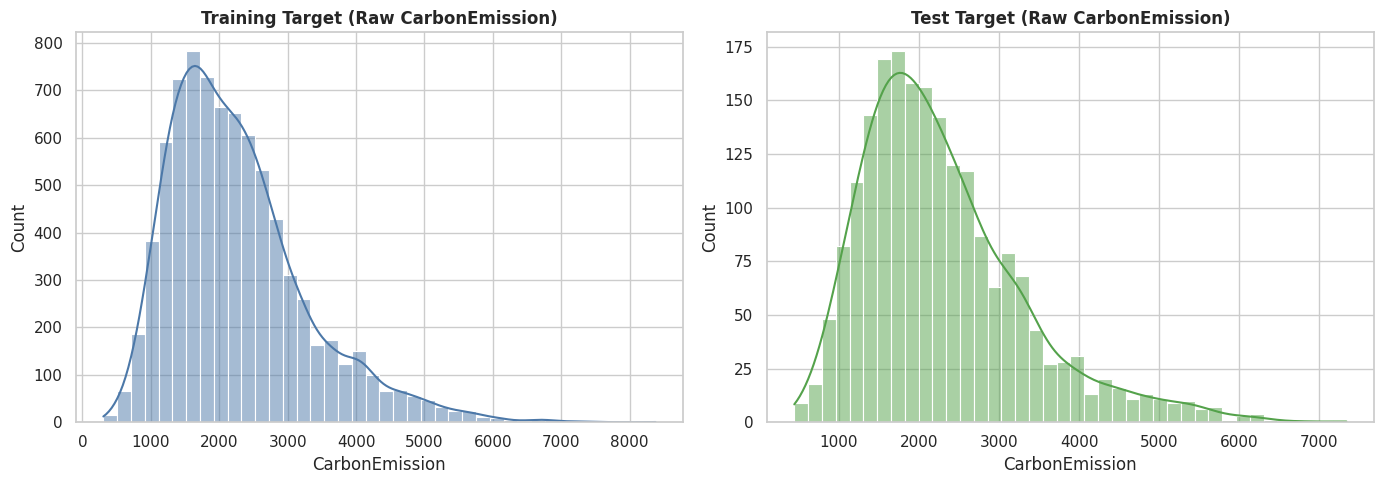

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(y_train_orig, bins=40, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Training Target (Raw CarbonEmission)")
axes[0].set_xlabel("CarbonEmission")

sns.histplot(y_test_orig, bins=40, kde=True, ax=axes[1], color="#54A24B")
axes[1].set_title("Test Target (Raw CarbonEmission)")
axes[1].set_xlabel("CarbonEmission")

plt.tight_layout()
plt.show()


## 4. Metric Helpers

All final metrics are computed on the original carbon-emission scale. The model learns the raw `CarbonEmission` target, so predictions are used directly.

In [ ]:
def compute_metrics(y_true_orig, y_pred_orig):
    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2   = r2_score(y_true_orig, y_pred_orig)
    mape = np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-9))) * 100
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}


def log_metrics(name, metrics, prefix=""):
    log(f"{prefix}{name}")
    log(f"  MAE:  {metrics['MAE']:.4f}")
    log(f"  RMSE: {metrics['RMSE']:.4f}")
    log(f"  R2:   {metrics['R2']:.4f}")
    log(f"  MAPE: {metrics['MAPE']:.4f}%")


def cv_score(model, X, y, folds=CV_FOLDS):
    kf = KFold(n_splits=folds, shuffle=True, random_state=RANDOM_SEED)
    fold_rows = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)  # raw scale — no expm1 needed
        metrics = compute_metrics(y_val, preds)
        metrics["Fold"] = fold
        fold_rows.append(metrics)

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        metric: {"mean": fold_df[metric].mean(), "std": fold_df[metric].std(ddof=0)}
        for metric in ["MAE", "RMSE", "R2", "MAPE"]
    }
    return summary, fold_df


## 5. Model Availability

The project compares all five models: Ridge Regression, Random Forest, XGBoost, LightGBM, and CatBoost. If any package is missing, install the dependencies from the setup cell before running the notebook.

In [ ]:
# Real availability check (rather than a hardcoded all-True dict).
# Cell 40 already raises ImportError if any of these are missing, so this
# will show all True in a working environment — but now it's an actual
# check, not just something that looks like one.
_model_packages = {
    "Ridge Regression": "sklearn",
    "Random Forest": "sklearn",
    "XGBoost": "xgboost",
    "LightGBM": "lightgbm",
    "CatBoost": "catboost",
}
model_availability = {name: find_spec(pkg) is not None for name, pkg in _model_packages.items()}

display(pd.DataFrame({
    "Model": list(model_availability.keys()),
    "Available": list(model_availability.values()),
}))


## 6. Baseline Training

Baseline models use simple default or near-default hyperparameters. This gives a reference point before tuning.

In [ ]:
log("STEP 4a - BASELINE TRAINING")

baselines = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
}

baselines["XGBoost"] = XGBRegressor(
    n_estimators=200,
    random_state=RANDOM_SEED,
    verbosity=0,
)

baselines["LightGBM"] = LGBMRegressor(
    n_estimators=200,
    random_state=RANDOM_SEED,
    verbose=-1,
)

baselines["CatBoost"] = CatBoostRegressor(
    iterations=200,
    random_seed=RANDOM_SEED,
    verbose=0,
)

baseline_results = {}
baseline_predictions = {}

for name, model in baselines.items():
    t0 = time.time()
    X_tr = X_train_s if name == "Ridge Regression" else X_train
    X_te = X_test_s if name == "Ridge Regression" else X_test

    model.fit(X_tr, y_train)

    # Raw-target pipeline: predictions are already CarbonEmission values.
    preds_orig = model.predict(X_te)
    metrics = compute_metrics(y_test_orig, preds_orig)

    baseline_results[name] = metrics
    baseline_predictions[name] = preds_orig
    log_metrics(name, metrics, prefix=f"[{time.time() - t0:.1f}s] ")

baseline_df = pd.DataFrame.from_dict(baseline_results, orient="index").reset_index(names="Model")
display(baseline_df.sort_values("R2", ascending=False))


STEP 4a - BASELINE TRAINING
[0.0s] Ridge Regression
  MAE:  205.0086
  RMSE: 284.9905
  R2:   0.9219
  MAPE: 10.5466%
[7.4s] Random Forest
  MAE:  221.0659
  RMSE: 288.8210
  R2:   0.9198
  MAPE: 10.6497%
[0.6s] XGBoost
  MAE:  122.0649
  RMSE: 162.3414
  R2:   0.9747
  MAPE: 5.7175%
[0.5s] LightGBM
  MAE:  97.1345
  RMSE: 131.9425
  R2:   0.9833
  MAPE: 4.4708%
[0.7s] CatBoost
  MAE:  70.5481
  RMSE: 97.3628
  R2:   0.9909
  MAPE: 3.1521%


,Model,MAE,RMSE,R2,MAPE
4,CatBoost,70.548118,97.362803,0.990883,3.152086
3,LightGBM,97.134531,131.942532,0.983256,4.470786
2,XGBoost,122.064919,162.341407,0.974652,5.717517
0,Ridge Regression,205.008553,284.990457,0.921882,10.546613
1,Random Forest,221.065935,288.821035,0.919768,10.649689


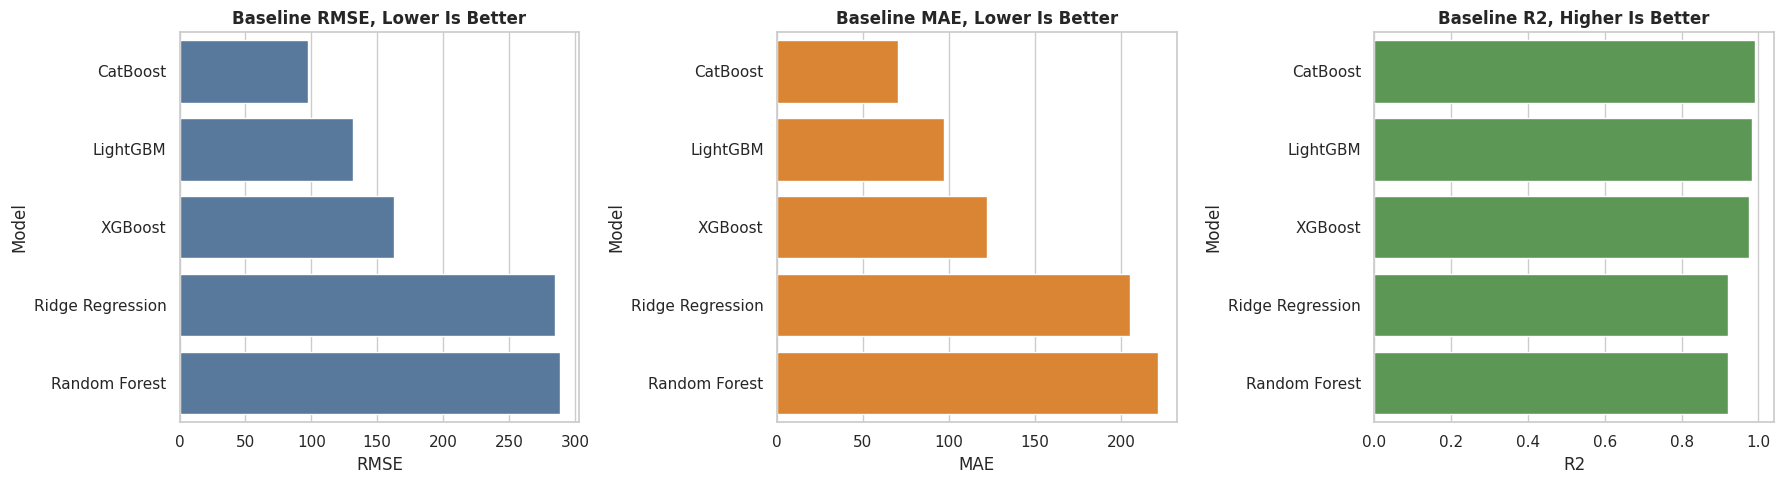

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=baseline_df.sort_values("RMSE"), x="RMSE", y="Model", ax=axes[0], color="#4C78A8")
axes[0].set_title("Baseline RMSE, Lower Is Better")

sns.barplot(data=baseline_df.sort_values("MAE"), x="MAE", y="Model", ax=axes[1], color="#F58518")
axes[1].set_title("Baseline MAE, Lower Is Better")

sns.barplot(data=baseline_df.sort_values("R2", ascending=False), x="R2", y="Model", ax=axes[2], color="#54A24B")
axes[2].set_title("Baseline R2, Higher Is Better")

plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning

Each model family is tuned the way that suits its cost profile:

- **Ridge** — `RidgeCV` (closed-form, exact, no Optuna needed).
- **Random Forest** — Optuna with a small budget (`RF_TRIALS`), scored
  against the model's own out-of-bag (OOB) predictions instead of k-fold
  CV. RF is flat-surfaced (it barely overfits its own hyperparameters) and
  OOB scoring needs no extra folds, so a bigger search buys little.
- **XGBoost / LightGBM / CatBoost** — Optuna with a larger budget
  (`BOOST_TRIALS`), using early stopping (or CatBoost's native
  overfitting detector) on an internal validation split so the search
  never has to spend trials on `n_estimators`/`iterations` directly.

If `RUN_OPTUNA` is `False`, tuned models fall back to sensible
baseline-style configurations so the rest of the notebook can still run.


In [ ]:
log("STEP 4b - HYPERPARAMETER TUNING")
if RUN_OPTUNA:
    log("Optuna is ENABLED (RUN_OPTUNA=True). Tree models will be tuned via Bayesian search.")
    log(f"  Random Forest trials: {RF_TRIALS} (tuned against OOB score, no CV folds needed)")
    log(f"  Boosting model trials (XGBoost/LightGBM/CatBoost): {BOOST_TRIALS} each "
        f"(early stopping on an internal validation split)")
else:
    log("Optuna is DISABLED (RUN_OPTUNA=False). Using pre-tuned fixed hyperparameters.")
    log("  Set RUN_OPTUNA=True in the config cell to enable Bayesian tuning.")

def tune_ridge():
    alphas = np.logspace(-3, 4, 50)
    ridge_cv = RidgeCV(alphas=alphas, cv=CV_FOLDS)
    ridge_cv.fit(X_train_s, y_train)
    return Ridge(alpha=ridge_cv.alpha_), {"alpha": float(ridge_cv.alpha_)}


# Internal holdout used by the boosting models (XGBoost, LightGBM, CatBoost)
# for early stopping during Optuna trials. This is separate from the
# outer train/test split — it only exists to give each boosting model a
# validation signal so it can pick its own iteration count per trial,
# instead of searching n_estimators/iterations as a hyperparameter.
X_tr_inner, X_val_inner, y_tr_inner, y_val_inner = train_test_split(
    X_train, y_train, test_size=0.15, random_state=RANDOM_SEED,
)


tuned_models     = {}
tuning_details   = []
optional_studies = {}

ridge_tuned, ridge_params = tune_ridge()
tuned_models["Ridge Regression"] = ridge_tuned
tuning_details.append({"Model": "Ridge Regression", "Tuned": True, "Best_Params": ridge_params})
optional_studies["Ridge Regression"] = None  # Ridge is tuned via RidgeCV, not Optuna
log(f"Ridge best alpha: {ridge_params}")


In [ ]:
# Random Forest — tuned via Optuna when RUN_OPTUNA=True, else fixed params.
#
# Unlike the boosting models below, Random Forest does not need k-fold CV
# to get an honest validation score: with bootstrap=True, every tree is
# grown on a bootstrap resample, so each training row is naturally held
# out of roughly a third of the trees. Averaging predictions from only the
# trees that did NOT see a given row gives an out-of-bag (OOB) prediction
# for free, with no extra fitting. That is why RF_TRIALS is much smaller
# than the boosting models' budget — OOB scoring is cheap per trial, and
# RF also barely overfits its own hyperparameters, so a small/medium
# search is enough to find a good configuration.
if RUN_OPTUNA:
    def rf_objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 600),
            "max_depth": trial.suggest_int("max_depth", 4, 30),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
            "max_features": trial.suggest_float("max_features", 0.3, 1.0),
            "random_state": RANDOM_SEED,
            "n_jobs": -1,
            "bootstrap": True,
            "oob_score": True,
        }
        model = RandomForestRegressor(**params)
        model.fit(X_train, y_train)
        # oob_prediction_ holds each row's prediction from only the trees
        # that never saw it during training — an honest validation signal
        # without any separate CV loop.
        oob_preds = model.oob_prediction_
        return float(np.sqrt(mean_squared_error(y_train, oob_preds)))

    rf_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    rf_study.optimize(rf_objective, n_trials=RF_TRIALS, show_progress_bar=False)
    rf_params = dict(rf_study.best_params)
    rf_params.update({"random_state": RANDOM_SEED, "n_jobs": -1})
else:
    rf_study = None
    rf_params = {
        "n_estimators": 200, "max_depth": None, "min_samples_split": 5,
        "min_samples_leaf": 2, "max_features": 0.5, "random_state": RANDOM_SEED, "n_jobs": -1,
    }

rf_tuned = RandomForestRegressor(**rf_params)
tuned_models["Random Forest"] = rf_tuned
tuning_details.append({"Model": "Random Forest", "Tuned": RUN_OPTUNA, "Best_Params": rf_params})
optional_studies["Random Forest"] = rf_study
log(f"Random Forest params: {rf_params}")


In [ ]:
# XGBoost — tuned via Optuna when RUN_OPTUNA=True, else fixed params.
#
# n_estimators is no longer searched directly: instead we give the model
# a high ceiling and let early stopping (on the internal X_val_inner
# holdout defined above) pick the actual number of trees for each trial.
# That frees up the trial budget (BOOST_TRIALS) for the params that
# actually change model behaviour: learning_rate, depth, subsampling,
# and regularization.
if RUN_OPTUNA:
    def xgb_objective(trial):
        params = {
            "n_estimators": 3000,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
            "random_state": RANDOM_SEED,
            "verbosity": 0,
            "early_stopping_rounds": 50,
        }
        model = XGBRegressor(**params)
        model.fit(
            X_tr_inner, y_tr_inner,
            eval_set=[(X_val_inner, y_val_inner)],
            verbose=False,
        )
        preds = model.predict(X_val_inner)
        # Remember the early-stopped iteration count so the winning
        # trial's tree count can be reused for the final refit below.
        trial.set_user_attr("best_iteration", int(model.best_iteration))
        return float(np.sqrt(mean_squared_error(y_val_inner, preds)))

    xgb_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    xgb_study.optimize(xgb_objective, n_trials=BOOST_TRIALS, show_progress_bar=False)
    xgb_params = dict(xgb_study.best_params)
    best_iter = xgb_study.best_trial.user_attrs.get("best_iteration", 700)
    xgb_params.update({
        "random_state": RANDOM_SEED,
        "verbosity": 0,
        # Refit on the full training set with a fixed tree count — a small
        # buffer above the early-stopped count from the winning trial,
        # since the full training set is larger than X_tr_inner.
        "n_estimators": int(best_iter * 1.15) + 1,
    })
else:
    xgb_study = None
    xgb_params = {
        "n_estimators": 700, "learning_rate": 0.08, "max_depth": 3,
        "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 5,
        "reg_alpha": 0.1, "reg_lambda": 1, "random_state": RANDOM_SEED, "verbosity": 0,
    }

tuned_models["XGBoost"] = XGBRegressor(**xgb_params)
tuning_details.append({"Model": "XGBoost", "Tuned": RUN_OPTUNA, "Best_Params": xgb_params})
optional_studies["XGBoost"] = xgb_study
log(f"XGBoost params: {xgb_params}")


In [ ]:
# LightGBM — tuned via Optuna when RUN_OPTUNA=True, else fixed params.
# Same idea as XGBoost above: give it a high n_estimators ceiling and let
# early stopping on the internal validation split pick the real count,
# freeing the trial budget for num_leaves (LightGBM's most sensitive
# knob), depth, subsampling, and regularization.
import lightgbm as lgb

if RUN_OPTUNA:
    def lgbm_objective(trial):
        params = {
            "n_estimators": 3000,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127),
            "max_depth": trial.suggest_int("max_depth", 3, 14),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
            "random_state": RANDOM_SEED,
            "verbose": -1,
        }
        model = LGBMRegressor(**params)
        model.fit(
            X_tr_inner, y_tr_inner,
            eval_set=[(X_val_inner, y_val_inner)],
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )
        preds = model.predict(X_val_inner)
        trial.set_user_attr("best_iteration", int(model.best_iteration_))
        return float(np.sqrt(mean_squared_error(y_val_inner, preds)))

    lgbm_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    lgbm_study.optimize(lgbm_objective, n_trials=BOOST_TRIALS, show_progress_bar=False)
    lgbm_params = dict(lgbm_study.best_params)
    best_iter = lgbm_study.best_trial.user_attrs.get("best_iteration", 500)
    lgbm_params.update({
        "random_state": RANDOM_SEED,
        "verbose": -1,
        "n_estimators": int(best_iter * 1.15) + 1,
    })
else:
    lgbm_study = None
    lgbm_params = {
        "n_estimators": 500, "learning_rate": 0.08, "num_leaves": 15, "max_depth": 12,
        "min_child_samples": 40, "subsample": 0.7, "colsample_bytree": 0.6,
        "reg_alpha": 1, "reg_lambda": 0.1, "random_state": RANDOM_SEED, "verbose": -1,
    }

tuned_models["LightGBM"] = LGBMRegressor(**lgbm_params)
tuning_details.append({"Model": "LightGBM", "Tuned": RUN_OPTUNA, "Best_Params": lgbm_params})
optional_studies["LightGBM"] = lgbm_study
log(f"LightGBM params: {lgbm_params}")


In [ ]:
# CatBoost — tuned via Optuna when RUN_OPTUNA=True, else fixed params.
# CatBoost has a built-in overfitting detector: instead of tuning
# `iterations` as a hyperparameter, give it a high ceiling and let
# od_type="Iter" with od_wait=50 stop training once the validation
# metric hasn't improved for 50 rounds — CatBoost's native equivalent of
# the early stopping used for XGBoost/LightGBM above.
if RUN_OPTUNA:
    def cat_objective(trial):
        params = {
            "iterations": 3000,
            "depth": trial.suggest_int("depth", 4, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "od_type": "Iter",
            "od_wait": 50,
            "random_seed": RANDOM_SEED,
            "verbose": 0,
        }
        model = CatBoostRegressor(**params)
        model.fit(X_tr_inner, y_tr_inner, eval_set=(X_val_inner, y_val_inner), use_best_model=True)
        preds = model.predict(X_val_inner)
        trial.set_user_attr("best_iteration", int(model.get_best_iteration()))
        return float(np.sqrt(mean_squared_error(y_val_inner, preds)))

    cat_study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    cat_study.optimize(cat_objective, n_trials=BOOST_TRIALS, show_progress_bar=False)
    cat_params = dict(cat_study.best_params)
    best_iter = cat_study.best_trial.user_attrs.get("best_iteration", 500)
    cat_params.update({
        "random_seed": RANDOM_SEED,
        "verbose": 0,
        "iterations": int(best_iter * 1.15) + 1,
    })
else:
    cat_study = None
    cat_params = {
        "iterations": 500,
        "learning_rate": 0.05,
        "depth": 6,
        "random_seed": RANDOM_SEED,
        "verbose": 0,
    }

tuned_models["CatBoost"] = CatBoostRegressor(**cat_params)
tuning_details.append({"Model": "CatBoost", "Tuned": RUN_OPTUNA, "Best_Params": cat_params})
optional_studies["CatBoost"] = cat_study
log(f"CatBoost params: {cat_params}")

tuning_df = pd.DataFrame(tuning_details)
display(tuning_df)


## 8. Tuning Diagnostics

When Optuna is available, the studies can be inspected to see whether search improved over trials. These plots are helpful for deciding whether more trials are worthwhile.

,best_log_cv_rmse
Model,
CatBoost,91.873032


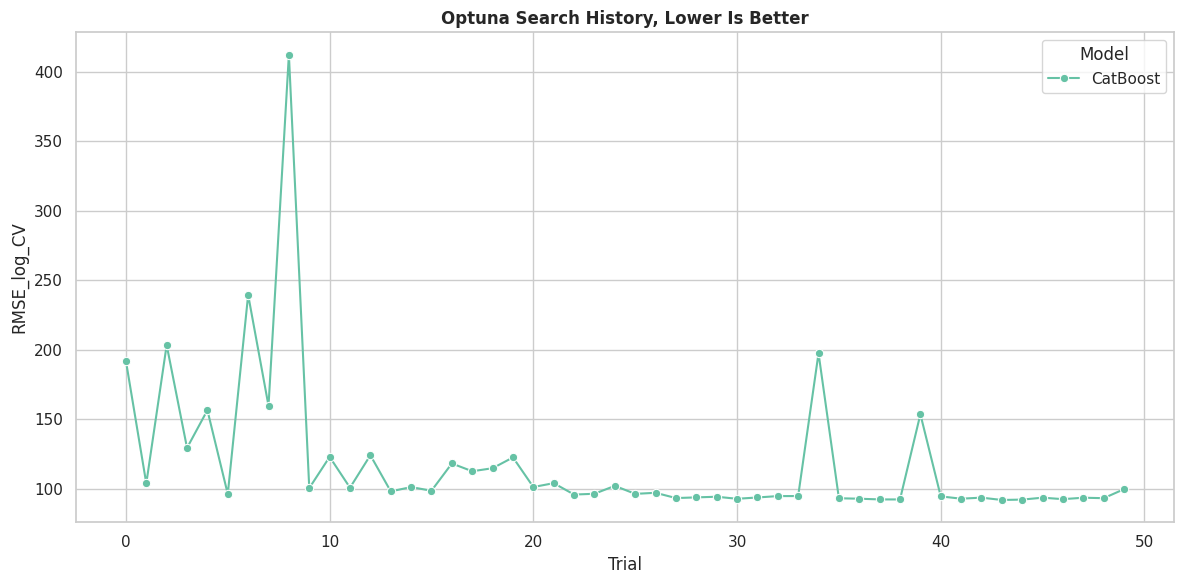

In [ ]:
study_rows = []
for model_name, study in optional_studies.items():
    if study is None:
        continue
    for trial in study.trials:
        if trial.value is not None:
            study_rows.append({
                "Model": model_name,
                "Trial": trial.number,
                "Validation_RMSE": trial.value,
            })

study_df = pd.DataFrame(study_rows)

if study_df.empty:
    if not RUN_OPTUNA:
        print("Tuning diagnostics: Optuna was disabled (RUN_OPTUNA=False).")
        print("Showing the fixed hyperparameters used instead:\n")
        param_rows = []
        for detail in tuning_details:
            for param, val in detail["Best_Params"].items():
                param_rows.append({"Model": detail["Model"], "Parameter": param, "Value": val})
        display(pd.DataFrame(param_rows))
    else:
        print("No Optuna study history found — all studies returned None.")
else:
    display(study_df.groupby("Model")["Validation_RMSE"].min().sort_values().to_frame("Best Validation RMSE"))
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=study_df, x="Trial", y="Validation_RMSE", hue="Model", marker="o")
    plt.title("Optuna Search History — Lower Is Better")
    plt.xlabel("Trial number")
    plt.ylabel("Validation RMSE (OOB for RF, holdout for boosters)")
    plt.tight_layout()
    plt.show()


## 9. Cross-Validation of Tuned Models

Cross-validation estimates how stable each tuned model is across folds. Metrics are reported on the original target scale.

In [ ]:
log("STEP 4c - CROSS-VALIDATION")

cv_results = {}
cv_fold_frames = []

for name, model in tuned_models.items():
    log(f"Running CV: {name}")
    t0 = time.time()
    X_cv = X_train_s if name == "Ridge Regression" else X_train
    summary, fold_df = cv_score(model, X_cv, y_train)
    cv_results[name] = summary
    fold_df.insert(0, "Model", name)
    cv_fold_frames.append(fold_df)
    log(f"  RMSE: {summary['RMSE']['mean']:.4f} +/- {summary['RMSE']['std']:.4f}")
    log(f"  R2:   {summary['R2']['mean']:.4f} +/- {summary['R2']['std']:.4f}")
    log(f"  Time: {time.time() - t0:.1f}s")

cv_folds_df = pd.concat(cv_fold_frames, ignore_index=True)
cv_summary_df = pd.DataFrame([
    {
        "Model": name,
        "CV_MAE_mean": values["MAE"]["mean"],
        "CV_MAE_std": values["MAE"]["std"],
        "CV_RMSE_mean": values["RMSE"]["mean"],
        "CV_RMSE_std": values["RMSE"]["std"],
        "CV_R2_mean": values["R2"]["mean"],
        "CV_R2_std": values["R2"]["std"],
        "CV_MAPE_mean": values["MAPE"]["mean"],
        "CV_MAPE_std": values["MAPE"]["std"],
    }
    for name, values in cv_results.items()
]).sort_values("CV_RMSE_mean")

display(cv_summary_df)

STEP 4c - CROSS-VALIDATION
Running CV: Ridge Regression
  RMSE: 290.9618 +/- 7.8913
  R2:   0.9181 +/- 0.0026
  Time: 0.0s
Running CV: Random Forest
  RMSE: 289.5253 +/- 6.4729
  R2:   0.9188 +/- 0.0047
  Time: 22.7s
Running CV: XGBoost
  RMSE: 109.2260 +/- 1.9887
  R2:   0.9884 +/- 0.0007
  Time: 5.3s
Running CV: LightGBM
  RMSE: 118.2245 +/- 2.7945
  R2:   0.9865 +/- 0.0008
  Time: 2.8s
Running CV: CatBoost
  RMSE: 89.8491 +/- 2.0260
  R2:   0.9922 +/- 0.0004
  Time: 6.6s


,Model,CV_MAE_mean,CV_MAE_std,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std,CV_MAPE_mean,CV_MAPE_std
4,CatBoost,65.280121,1.276571,89.849089,2.026022,0.992183,0.000351,2.978946,0.061293
2,XGBoost,79.935124,1.482928,109.225985,1.988676,0.988436,0.000694,3.752120,0.078381
3,LightGBM,85.876880,1.393232,118.224523,2.794461,0.986456,0.000802,4.012286,0.019090
1,Random Forest,217.440458,2.691986,289.525332,6.472912,0.918777,0.004686,10.898796,0.350561
0,Ridge Regression,210.089001,4.673422,290.961827,7.891327,0.918082,0.002554,10.890697,0.304507


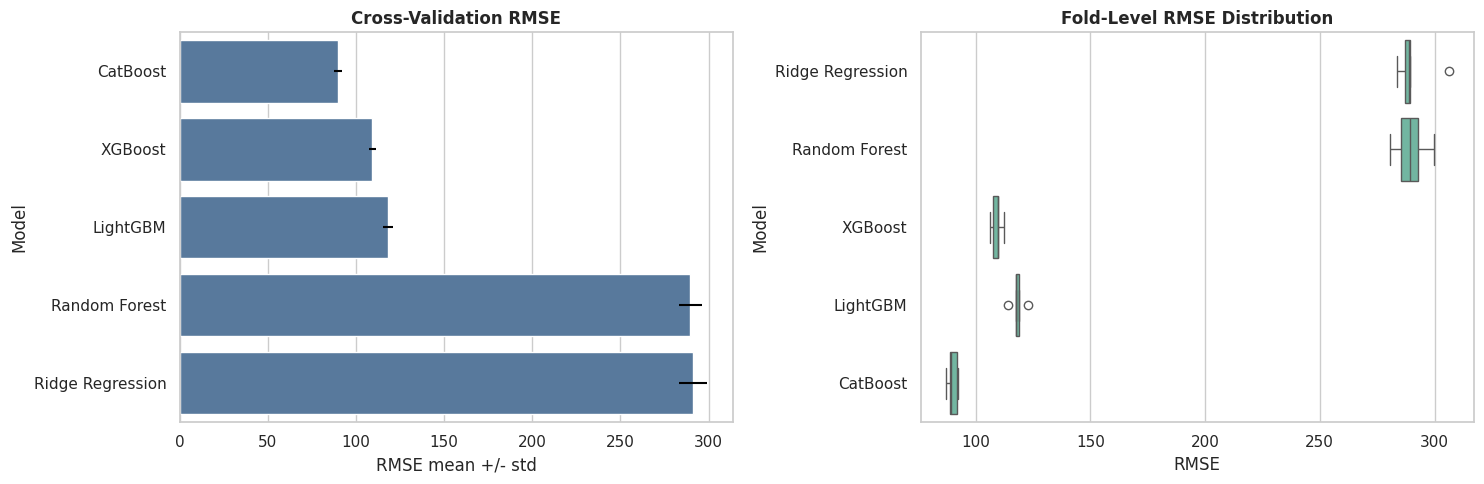

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=cv_summary_df, x="CV_RMSE_mean", y="Model", xerr=cv_summary_df["CV_RMSE_std"], ax=axes[0], color="#4C78A8")
axes[0].set_title("Cross-Validation RMSE")
axes[0].set_xlabel("RMSE mean +/- std")

sns.boxplot(data=cv_folds_df, x="RMSE", y="Model", ax=axes[1])
axes[1].set_title("Fold-Level RMSE Distribution")

plt.tight_layout()
plt.show()

## 10. Final Test-Set Evaluation

Each tuned model is retrained on the full training set and evaluated on the held-out test set. This is the final comparison table used for model selection.

In [ ]:
log("STEP 4d - FINAL TEST SET EVALUATION + TRAIN VS TEST COMPARISON")

final_results        = {}
final_train_results  = {}
final_predictions    = {}
fitted_models        = {}

for name, model in tuned_models.items():
    t0 = time.time()
    X_tr = X_train_s if name == "Ridge Regression" else X_train
    X_te = X_test_s  if name == "Ridge Regression" else X_test

    model.fit(X_tr, y_train)

    train_preds = model.predict(X_tr)
    test_preds  = model.predict(X_te)

    train_metrics = compute_metrics(y_train, train_preds)
    test_metrics  = compute_metrics(y_test_orig, test_preds)

    final_results[name]       = test_metrics
    final_train_results[name] = train_metrics
    final_predictions[name]   = test_preds
    fitted_models[name]       = model
    log_metrics(name, test_metrics, prefix=f"[{time.time()-t0:.1f}s] TEST  ")
    log_metrics(name, train_metrics, prefix=f"       TRAIN ")

final_df = pd.DataFrame.from_dict(final_results, orient="index").reset_index(names="Model")
final_df = final_df.sort_values("RMSE")

# ── Train vs Test comparison table ───────────────────────────────────
trte_rows = []
for name in fitted_models:
    tr = final_train_results[name]
    te = final_results[name]
    trte_rows.append({
        "Model":      name,
        "Train R²":   round(tr["R2"],   4),
        "Test R²":    round(te["R2"],   4),
        "R² Gap":     round(abs(tr["R2"]   - te["R2"]),   4),
        "Train RMSE": round(tr["RMSE"], 2),
        "Test RMSE":  round(te["RMSE"], 2),
        "RMSE Gap":   round(abs(te["RMSE"] - tr["RMSE"]), 2),
        "Train MAE":  round(tr["MAE"],  2),
        "Test MAE":   round(te["MAE"],  2),
        "MAE Gap":    round(abs(te["MAE"]  - tr["MAE"]),  2),
        "Overfit?":   "⚠️ Yes" if abs(tr["R2"] - te["R2"]) > 0.05 else "✅ No",
    })

trte_df = pd.DataFrame(trte_rows).sort_values("Test R²", ascending=False)
print("\n── Train vs Test Accuracy Comparison ──")
display(trte_df)

# Model selection uses cv_summary_df (5-fold CV on TRAINING data only,
# computed in the "Cross-Validation of Tuned Models" section above) —
# NOT final_df's test RMSE. Picking the winner by test-set performance
# and then reporting that same test set's score is test-set leakage at
# the model-selection level: it silently inflates the reported metric
# for whichever model got lucky on this particular test split. The test
# set is touched exactly once below, to report the already-selected
# model's generalization performance — never to choose among candidates.
best_model_name  = cv_summary_df.sort_values("CV_RMSE_mean").iloc[0]["Model"]
best_model       = fitted_models[best_model_name]
best_predictions = final_predictions[best_model_name]
log(f"Best model selected by CV RMSE (leakage-safe, training data only): {best_model_name}")
log(f"  CV RMSE (selection criterion): "
    f"{cv_summary_df.set_index('Model').loc[best_model_name, 'CV_RMSE_mean']:.4f}")
log(f"  Test RMSE (reported once, for the already-selected model): "
    f"{final_df.set_index('Model').loc[best_model_name, 'RMSE']:.4f}")


STEP 4d - FINAL TEST SET EVALUATION
[0.0s] Ridge Regression
  MAE:  205.0010
  RMSE: 284.9923
  R2:   0.9219
  MAPE: 10.5432%
[6.2s] Random Forest
  MAE:  213.6335
  RMSE: 282.6706
  R2:   0.9231
  MAPE: 10.3016%
[0.7s] XGBoost
  MAE:  78.4488
  RMSE: 106.7355
  R2:   0.9890
  MAPE: 3.5649%
[0.7s] LightGBM
  MAE:  83.3235
  RMSE: 113.4364
  R2:   0.9876
  MAPE: 3.8691%
[1.5s] CatBoost
  MAE:  66.9291
  RMSE: 91.2366
  R2:   0.9920
  MAPE: 2.9948%


,Model,MAE,RMSE,R2,MAPE
4,CatBoost,66.929116,91.236614,0.991994,2.994848
2,XGBoost,78.448814,106.735513,0.989043,3.564872
3,LightGBM,83.323476,113.436428,0.987624,3.869090
1,Random Forest,213.633524,282.670626,0.923149,10.301586
0,Ridge Regression,205.001016,284.992257,0.921881,10.543178


Best model by test RMSE: CatBoost


In [ ]:
comparison_rows = []
for name in final_results:
    row = {"Model": name}
    for key, value in baseline_results[name].items():
        row[f"Baseline_{key}"] = value
    for key, value in final_train_results[name].items():
        row[f"Train_{key}"] = value
    for key, value in final_results[name].items():
        row[f"Tuned_{key}"] = value
    if name in cv_results:
        row["CV_RMSE_mean"] = cv_results[name]["RMSE"]["mean"]
        row["CV_RMSE_std"]  = cv_results[name]["RMSE"]["std"]
        row["CV_R2_mean"]   = cv_results[name]["R2"]["mean"]
        row["CV_R2_std"]    = cv_results[name]["R2"]["std"]
    comparison_rows.append(row)

results_df = pd.DataFrame(comparison_rows).sort_values("Tuned_RMSE")
display(results_df)


,Model,Baseline_MAE,Baseline_RMSE,Baseline_R2,Baseline_MAPE,Tuned_MAE,Tuned_RMSE,Tuned_R2,Tuned_MAPE,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std
4,CatBoost,70.548118,97.362803,0.990883,3.152086,66.929116,91.236614,0.991994,2.994848,89.849089,2.026022,0.992183,0.000351
2,XGBoost,122.064919,162.341407,0.974652,5.717517,78.448814,106.735513,0.989043,3.564872,109.225985,1.988676,0.988436,0.000694
3,LightGBM,97.134531,131.942532,0.983256,4.470786,83.323476,113.436428,0.987624,3.869090,118.224523,2.794461,0.986456,0.000802
1,Random Forest,221.065935,288.821035,0.919768,10.649689,213.633524,282.670626,0.923149,10.301586,289.525332,6.472912,0.918777,0.004686
0,Ridge Regression,205.008553,284.990457,0.921882,10.546613,205.001016,284.992257,0.921881,10.543178,290.961827,7.891327,0.918082,0.002554


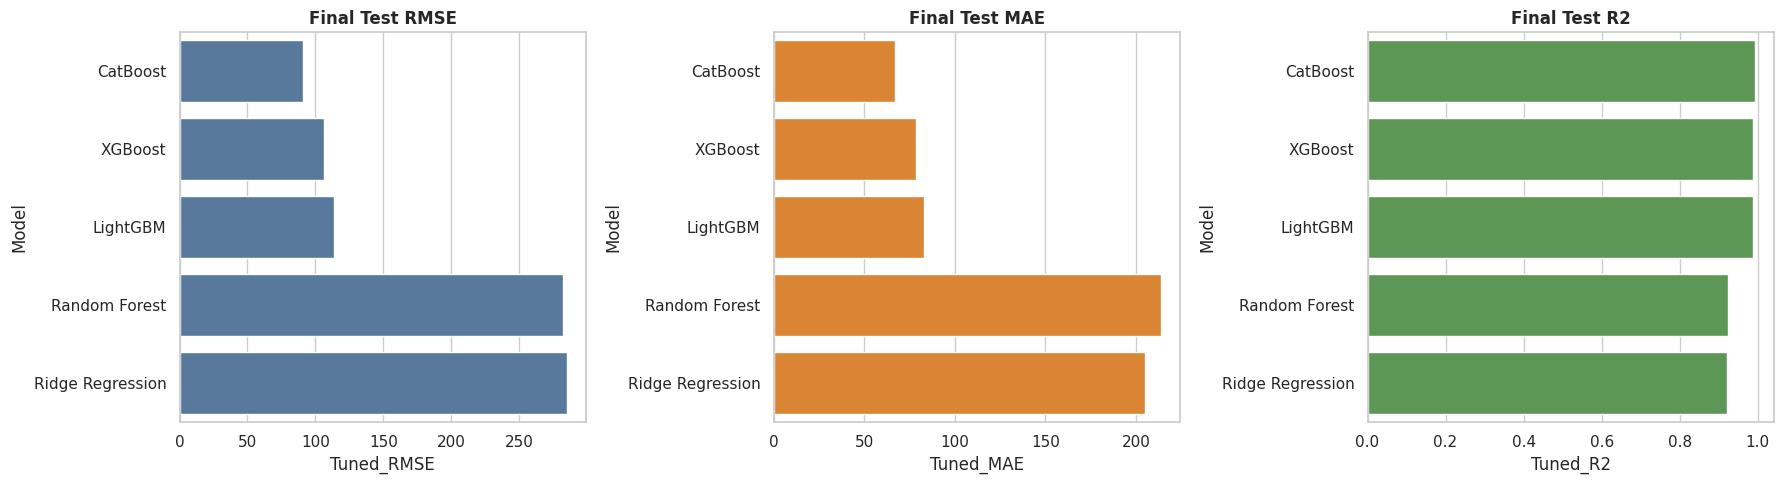

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results_df, x="Tuned_RMSE", y="Model", ax=axes[0], color="#4C78A8")
axes[0].set_title("Final Test RMSE")

sns.barplot(data=results_df, x="Tuned_MAE", y="Model", ax=axes[1], color="#F58518")
axes[1].set_title("Final Test MAE")

sns.barplot(data=results_df.sort_values("Tuned_R2", ascending=False), x="Tuned_R2", y="Model", ax=axes[2], color="#54A24B")
axes[2].set_title("Final Test R2")

plt.tight_layout()
plt.show()

## 11. Prediction Diagnostics for the Best Model

The best model is selected by lowest test RMSE. The following plots show prediction fit, residual distribution, and whether errors change across the emission range.

,count,mean,std,min,25%,50%,75%,max
Actual,2000.0,2291.512000,1019.915901,443.000000,1568.000000,2087.000000,2791.750000,7337.000000
Predicted,2000.0,2296.107988,1013.458984,431.439662,1579.526488,2107.486165,2799.194864,6737.131093
Residual,2000.0,-4.595988,91.143569,-561.131093,-56.370115,-4.921958,44.082662,613.454021
Absolute_Error,2000.0,66.929116,62.020452,0.006005,22.940976,49.105044,91.969992,613.454021


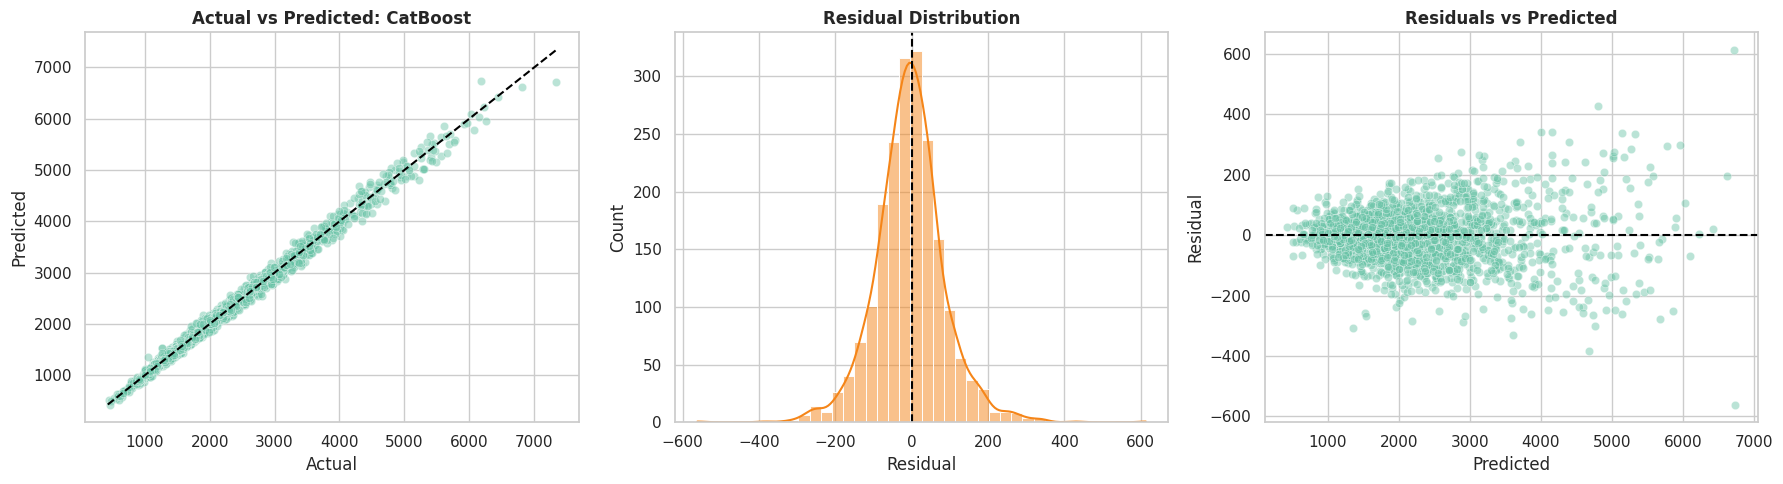

In [ ]:
diagnostics_df = pd.DataFrame({
    "Actual": y_test_orig,
    "Predicted": best_predictions,
})
diagnostics_df["Residual"] = diagnostics_df["Actual"] - diagnostics_df["Predicted"]
diagnostics_df["Absolute_Error"] = diagnostics_df["Residual"].abs()

display(diagnostics_df.describe().T)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=diagnostics_df, x="Actual", y="Predicted", alpha=0.45, ax=axes[0])
min_value = min(diagnostics_df["Actual"].min(), diagnostics_df["Predicted"].min())
max_value = max(diagnostics_df["Actual"].max(), diagnostics_df["Predicted"].max())
axes[0].plot([min_value, max_value], [min_value, max_value], color="black", linestyle="--")
axes[0].set_title(f"Actual vs Predicted: {best_model_name}")

sns.histplot(diagnostics_df["Residual"], kde=True, bins=40, ax=axes[1], color="#F58518")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residual Distribution")

sns.scatterplot(data=diagnostics_df, x="Predicted", y="Residual", alpha=0.45, ax=axes[2])
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

,Actual,Predicted,Residual,Absolute_Error,Row
831,7337,6723.545979,613.454021,613.454021,831
647,6176,6737.131093,-561.131093,561.131093,647
482,5229,4799.616754,429.383246,429.383246,482
1918,4300,4684.488314,-384.488314,384.488314,1918
1195,4342,3999.919657,342.080343,342.080343,1195
1853,4497,4155.062670,341.937330,341.937330,1853
914,5486,5148.495968,337.504032,337.504032,914
1130,5663,5326.416091,336.583909,336.583909,1130
44,3277,3607.248031,-330.248031,330.248031,44
746,4707,4399.112378,307.887622,307.887622,746


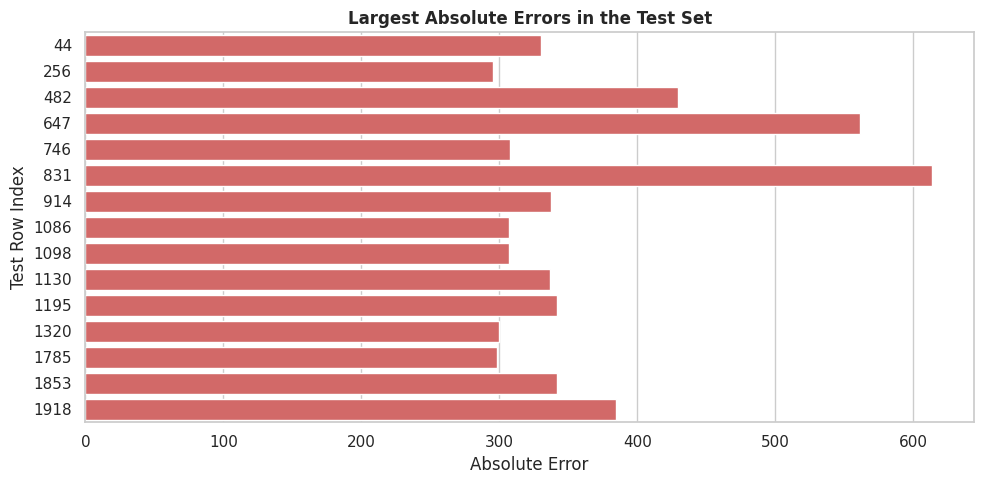

In [ ]:
top_error_df = diagnostics_df.assign(Row=np.arange(len(diagnostics_df))).sort_values("Absolute_Error", ascending=False).head(15)
display(top_error_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_error_df, x="Absolute_Error", y="Row", orient="h", color="#E45756")
plt.title("Largest Absolute Errors in the Test Set")
plt.xlabel("Absolute Error")
plt.ylabel("Test Row Index")
plt.tight_layout()
plt.show()

## 12. Feature Importance

For tree-based models, `feature_importances_` provides a quick global importance view. For Ridge Regression, absolute coefficient size is used as a linear-model proxy.

,Feature,Importance
0,Vehicle Monthly Distance Km,35.763844
1,Frequency of Traveling by Air,20.857754
2,Vehicle Type_electric,10.769093
3,Vehicle Type_petrol,5.444572
4,How Many New Clothes Monthly,4.011534
5,Sex_male,3.198922
6,Body Type_obese,3.142812
7,Waste Bag Weekly Count,3.070416
8,Waste Bag Size,2.605902
9,Heating Energy Source_coal,2.014576


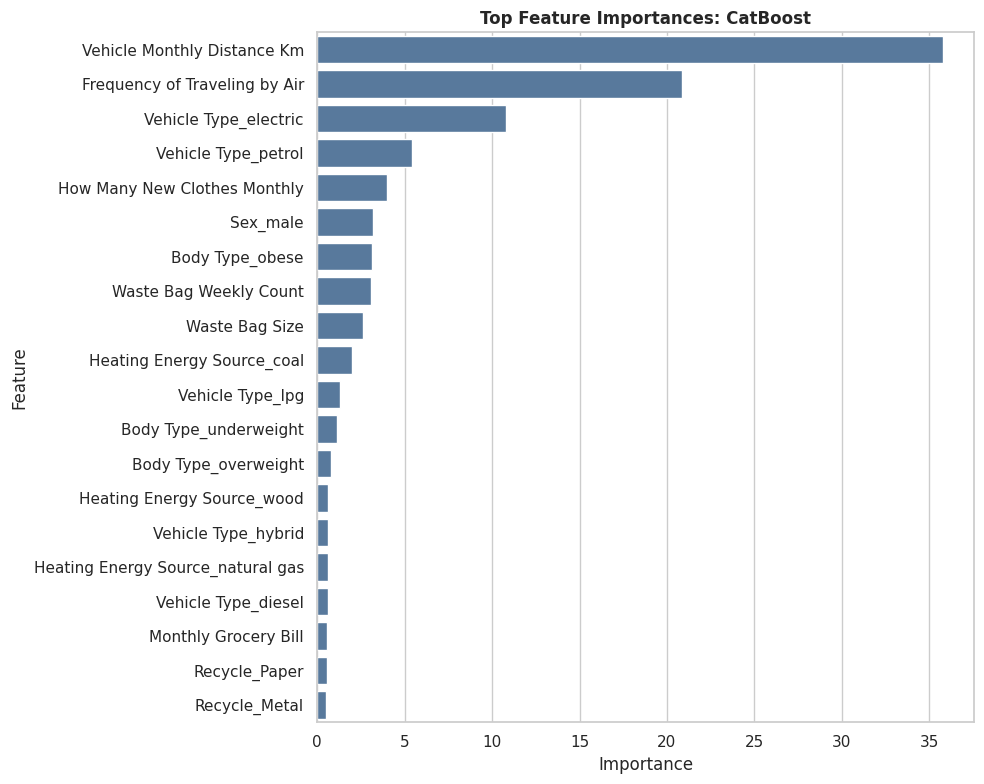

In [ ]:
def get_importance(model, model_name):
    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
    elif hasattr(model, "coef_"):
        values = np.abs(model.coef_)
    else:
        return pd.DataFrame(columns=["Feature", "Importance"])

    return (
        pd.DataFrame({"Feature": feature_names, "Importance": values})
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )

importance_df = get_importance(best_model, best_model_name)

if importance_df.empty:
    print(f"No feature importance attribute found for {best_model_name}.")
else:
    display(importance_df.head(20))
    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df.head(20), x="Importance", y="Feature", color="#4C78A8")
    plt.title(f"Top Feature Importances: {best_model_name}")
    plt.tight_layout()
    plt.show()

## 13. Save Models and Tables

The notebook saves all fitted available models, result tables, predictions, and a training report. All five tuned models are saved after training.

In [ ]:
model_file_names = {
    "Ridge Regression": "ridge_tuned.joblib",
    "Random Forest": "rf_tuned.joblib",
    "XGBoost": "xgb_tuned.joblib",
    "LightGBM": "lgbm_tuned.joblib",
    "CatBoost": "catboost_tuned.joblib",
}

for name, model in fitted_models.items():
    joblib.dump(model, MODELS_DIR / model_file_names[name])

results_df.round(6).to_csv(MODELS_DIR / "results_table.csv", index=False)
cv_summary_df.round(6).to_csv(MODELS_DIR / "cv_results.csv", index=False)

predictions_df = pd.DataFrame({"Actual": y_test_orig})
for name, preds in final_predictions.items():
    predictions_df[f"Predicted_{name}"] = preds
predictions_df.to_csv(MODELS_DIR / "test_predictions.csv", index=False)

tuning_df.to_csv(MODELS_DIR / "tuning_details.csv", index=False)

with open(MODELS_DIR / "training_report.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Saved model artifacts:")
for path in sorted(MODELS_DIR.iterdir()):
    print("-", path.name)

Saved model artifacts:
- catboost_tuned.joblib
- cv_results.csv
- lgbm_tuned.joblib
- results_table.csv
- rf_tuned.joblib
- ridge_tuned.joblib
- test_predictions.csv
- training_report.txt
- tuning_details.csv
- xgb_tuned.joblib


## 14. Loading Trained Models Later

Use the snippet below in SHAP analysis, clustering scripts, or deployment experiments. Remember that Ridge expects scaled features, while tree-based models expect the unscaled matrix.

In [ ]:
# Example loading pattern for later scripts.

loaded_results = pd.read_csv(MODELS_DIR / "results_table.csv")
display(loaded_results[["Model", "Tuned_MAE", "Tuned_RMSE", "Tuned_R2", "Tuned_MAPE"]])

loaded_best_name = loaded_results.sort_values("Tuned_RMSE").iloc[0]["Model"]
loaded_best_path = MODELS_DIR / model_file_names[loaded_best_name]
loaded_best_model = joblib.load(loaded_best_path)

print("Best saved model:", loaded_best_name)
print("Loaded from:", loaded_best_path)

,Model,Tuned_MAE,Tuned_RMSE,Tuned_R2,Tuned_MAPE
0,CatBoost,66.929116,91.236614,0.991994,2.994848
1,XGBoost,78.448814,106.735513,0.989043,3.564872
2,LightGBM,83.323476,113.436428,0.987624,3.869090
3,Random Forest,213.633524,282.670626,0.923149,10.301586
4,Ridge Regression,205.001016,284.992257,0.921881,10.543178


Best saved model: CatBoost
Loaded from: outputs/models/catboost_tuned.joblib


---

# Part 3: SHAP Explainability, Model Validation, Clustering, and Recommendations

This section runs after Parts 1 and 2 have completed. It loads the saved model artifacts from `outputs/models/` and the preprocessed arrays from `outputs/`, then generates SHAP explanations, permutation importance, clustering, stacking, counterfactuals, and prediction intervals.

> **Note:** All analyses use the raw `CarbonEmission` scale (no `expm1` needed).

# SHAP Explainability, Model Validation, Clustering, and Recommendations

This notebook combines the best parts of your `03_shap_explainability.ipynb` and the `shap_explainability.ipynb` generated earlier.

It includes:

- SHAP beeswarm, bar, waterfall, dependence, and force plots
- high / median / low user explanations
- cross-model SHAP comparison across Ridge, Random Forest, XGBoost, LightGBM, and CatBoost
- permutation importance for the best model and all models
- SHAP vs permutation agreement analysis
- SHAP-based feature pruning
- KMeans lifestyle archetype clustering
- stacking ensemble experiment
- counterfactual recommendation generation
- simple prediction interval estimation
- MAPE-objective LightGBM reference experiment

Run this after the updated full pipeline has saved raw-target files into `outputs/` and `outputs/models/`. Model predictions are already on the `CarbonEmission` kg scale, so no `np.expm1()` inverse transform is used.

## 1. Setup and Dependencies

If running in Colab, install the required packages first:

```python
!pip install shap optuna catboost xgboost lightgbm
```

In [ ]:
from importlib.util import find_spec
from pathlib import Path
import json
import warnings

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "shap": "shap",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "catboost": "catboost",
}
missing_packages = [pip_name for module_name, pip_name in required_packages.items() if find_spec(module_name) is None]
if missing_packages:
    raise ImportError(
        "Missing required packages: "
        + ", ".join(missing_packages)
        + ". Install them with: pip install "
        + " ".join(missing_packages)
    )

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.ensemble import StackingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import cross_val_predict

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Suppress noisy but harmless warnings; keep data-type and deprecation
# warnings from core libraries visible so we do not miss real issues.
warnings.filterwarnings("ignore", category=UserWarning)          # seaborn layout
warnings.filterwarnings("ignore", category=FutureWarning)        # pandas internals
warnings.filterwarnings("ignore", message=".*force_all_finite.*")# sklearn 1.6 rename
warnings.filterwarnings("ignore", message=".*n_features_in.*")   # sklearn estimator
# NOTE: RuntimeWarning and DeprecationWarning are intentionally NOT suppressed.
shap.initjs()

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

# RANDOM_SEED is defined once in Cell 5. Reuse it here.
# Assertion guard: fail fast if Cell 5 has not been run.
# NOTE: dir() lists names in the current scope including builtins and
# imported modules, so it can pass even when RANDOM_SEED was never set.
# globals() only contains names actually defined at the top level.
assert "RANDOM_SEED" in globals(), (
    "RANDOM_SEED is not defined. Run Cell 5 (Part 1 setup) first."
)
np.random.seed(RANDOM_SEED)  # global numpy seed for reproducibility of any
                              # Part 3 code that relies on it implicitly
                              # (e.g. KMeans internals), in case Part 3 is
                              # run fresh in a new kernel without Part 1.

OUTPUTS_DIR = Path("outputs")
MODELS_DIR = OUTPUTS_DIR / "models"
EXPLAIN_DIR = OUTPUTS_DIR / "explainability"
EXPLAIN_DIR.mkdir(parents=True, exist_ok=True)

print("All imports OK.")

# Part 3 reuses the master log() defined in Cell 5 (Part 1).
# If running Part 3 standalone (without Part 1), define a thin fallback:
if "log" not in dir():
    _fallback_lines = []
    def log(message=""):
        print(message)
        _fallback_lines.append(str(message))
    report_lines = _fallback_lines
    print("Note: log() fallback defined — run Cell 5 for unified reporting.")


## 2. Load Data and Models

This section loads preprocessed arrays, feature names, all five tuned models, and the best-model metadata when available.

In [ ]:
X_train = np.load(OUTPUTS_DIR / "X_train.npy")
X_test = np.load(OUTPUTS_DIR / "X_test.npy")
X_train_s = np.load(OUTPUTS_DIR / "X_train_scaled.npy")
X_test_s = np.load(OUTPUTS_DIR / "X_test_scaled.npy")
y_train = np.load(OUTPUTS_DIR / "y_train.npy")
y_test = np.load(OUTPUTS_DIR / "y_test.npy")

y_train_orig = y_train.copy()
y_test_orig = y_test.copy()

with open(OUTPUTS_DIR / "feature_names.json", encoding="utf-8") as f:
    feature_names = json.load(f)

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Features:", len(feature_names))

X_train: (8000, 36)
X_test: (2000, 36)
Features: 36


In [ ]:
model_file_map = {
    "Ridge Regression": ("ridge_tuned.joblib", X_train_s, X_test_s),
    "Random Forest": ("rf_tuned.joblib", X_train, X_test),
    "XGBoost": ("xgb_tuned.joblib", X_train, X_test),
    "LightGBM": ("lgbm_tuned.joblib", X_train, X_test),
    "CatBoost": ("catboost_tuned.joblib", X_train, X_test),
}

all_models = {}
missing_models = []
for name, (filename, _, _) in model_file_map.items():
    model_path = MODELS_DIR / filename
    if model_path.exists():
        all_models[name] = joblib.load(model_path)
        print("Loaded:", name)
    else:
        missing_models.append(filename)

if not all_models:
    raise FileNotFoundError("No trained models found in outputs/models/. Run model training first.")

if missing_models:
    print("Missing model files:", missing_models)

rf_tuned = all_models.get("Random Forest")
xgb_tuned = all_models.get("XGBoost")
lgbm_tuned = all_models.get("LightGBM")
cat_tuned = all_models.get("CatBoost")

Loaded: Ridge Regression
Loaded: Random Forest
Loaded: XGBoost
Loaded: LightGBM
Loaded: CatBoost


In [ ]:
def evaluate_original_scale(model, X_matrix, y_true_raw):
    preds = model.predict(X_matrix)
    y_true = y_true_raw
    return {
        "MAE": mean_absolute_error(y_true, preds),
        "RMSE": np.sqrt(mean_squared_error(y_true, preds)),
        "R2": r2_score(y_true, preds),
        "MAPE": np.mean(np.abs((y_true - preds) / y_true)) * 100,
    }

# Model selection here mirrors Part 2: prefer CV_RMSE_mean (5-fold CV on
# training data, saved into results_table.csv) over any test-set metric,
# to avoid picking a "best" model based on the same test set used to
# report its performance.
results_path = MODELS_DIR / "results_table.csv"
if results_path.exists():
    results_df = pd.read_csv(results_path)
    if "CV_RMSE_mean" in results_df.columns:
        display(results_df.sort_values("CV_RMSE_mean"))
        best_model_name = results_df.sort_values("CV_RMSE_mean").iloc[0]["Model"]
    else:
        best_model_name = None
else:
    results_df = pd.DataFrame()
    best_model_name = None

if best_model_name not in all_models:
    # No CV_RMSE_mean column available (results_table.csv missing, or from
    # an older run of Part 2 without CV) — there is no CV artifact to select
    # from, so this fallback has no choice but to score directly on the test
    # set. This path should only trigger if Part 2 hasn't been (re-)run with
    # the current pipeline; the primary selection above always prefers
    # CV_RMSE_mean over any test-set metric when it is available.
    print("WARNING: no CV-based results found in results_table.csv — falling "
          "back to test-set scoring to pick a model. Re-run Part 2's training "
          "notebook to get a leakage-safe, CV-based selection instead.")
    fallback_rows = []
    for name, model in all_models.items():
        _, _, X_te = model_file_map[name]
        metrics = evaluate_original_scale(model, X_te, y_test)
        fallback_rows.append({"Model": name, **metrics})
    fallback_df = pd.DataFrame(fallback_rows).sort_values("RMSE")
    display(fallback_df)
    best_model_name = fallback_df.iloc[0]["Model"]

best_model = all_models[best_model_name]
best_X_train = model_file_map[best_model_name][1]
best_X_test = model_file_map[best_model_name][2]

print("Best overall model (selected by CV RMSE):", best_model_name)

tree_candidates = ["LightGBM", "XGBoost", "CatBoost", "Random Forest"]
if not results_df.empty and "CV_RMSE_mean" in results_df.columns:
    ranked_trees = [name for name in results_df.sort_values("CV_RMSE_mean")["Model"] if name in tree_candidates and name in all_models]
else:
    ranked_trees = [name for name in tree_candidates if name in all_models]

if not ranked_trees:
    raise ValueError("No tree model available for TreeExplainer.")

best_tree_model_name = ranked_trees[0]
best_tree_model = all_models[best_tree_model_name]
X_tree_train = model_file_map[best_tree_model_name][1]
X_tree_test = model_file_map[best_tree_model_name][2]

print("Best tree model for SHAP (selected by CV RMSE):", best_tree_model_name)


,Model,Baseline_MAE,Baseline_RMSE,Baseline_R2,Baseline_MAPE,Tuned_MAE,Tuned_RMSE,Tuned_R2,Tuned_MAPE,CV_RMSE_mean,CV_RMSE_std,CV_R2_mean,CV_R2_std
0,CatBoost,70.548118,97.362803,0.990883,3.152086,66.929116,91.236614,0.991994,2.994848,89.849089,2.026022,0.992183,0.000351
1,XGBoost,122.064919,162.341407,0.974652,5.717517,78.448814,106.735513,0.989043,3.564872,109.225985,1.988676,0.988436,0.000694
2,LightGBM,97.134531,131.942532,0.983256,4.470786,83.323476,113.436428,0.987624,3.869090,118.224523,2.794461,0.986456,0.000802
3,Random Forest,221.065935,288.821035,0.919768,10.649689,213.633524,282.670626,0.923149,10.301586,289.525332,6.472912,0.918777,0.004686
4,Ridge Regression,205.008553,284.990457,0.921882,10.546613,205.001016,284.992257,0.921881,10.543178,290.961827,7.891327,0.918082,0.002554


Best overall model: CatBoost
Best tree model for SHAP: CatBoost


## 3. Compute SHAP Values

For the paper visuals, SHAP is computed on the best available tree model. Ridge is still included later in cross-model comparisons with `LinearExplainer`.

In [ ]:
def normalize_shap_values(raw_values):
    if isinstance(raw_values, list):
        raw_values = raw_values[0]
    values = np.asarray(raw_values)
    if values.ndim == 3:
        values = values[:, :, 0]
    return values


def normalize_expected_value(raw_expected):
    if isinstance(raw_expected, (list, tuple, np.ndarray)):
        return float(np.asarray(raw_expected).ravel()[0])
    return float(raw_expected)

print(f"Computing SHAP values for {best_tree_model_name} on {X_tree_test.shape[0]} test rows...")
explainer = shap.TreeExplainer(best_tree_model)
shap_values = normalize_shap_values(explainer.shap_values(X_tree_test))
expected_value = normalize_expected_value(explainer.expected_value)
X_for_shap = X_tree_test
X_for_shap_df = pd.DataFrame(X_for_shap, columns=feature_names)

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=expected_value,
    data=X_for_shap,
    feature_names=feature_names,
)

print("SHAP values shape:", shap_values.shape)
print(f"Base value, kg CO2: {expected_value:.1f}")

Computing SHAP values for CatBoost on 2000 test rows...
SHAP values shape: (2000, 36)
Base value, kg CO2: 2263.6


## 4. SHAP Global Importance

Mean absolute SHAP values show each feature's average impact on predictions.

,Feature,Mean_SHAP
0,Vehicle Monthly Distance Km,445.488260
1,Frequency of Traveling by Air,441.344203
2,How Many New Clothes Monthly,171.694762
3,Sex_male,165.684321
4,Waste Bag Weekly Count,143.763825
5,Body Type_obese,142.381618
6,Waste Bag Size,127.753065
7,Heating Energy Source_coal,125.856481
8,Vehicle Type_petrol,86.237834
9,Vehicle Type_electric,75.840243


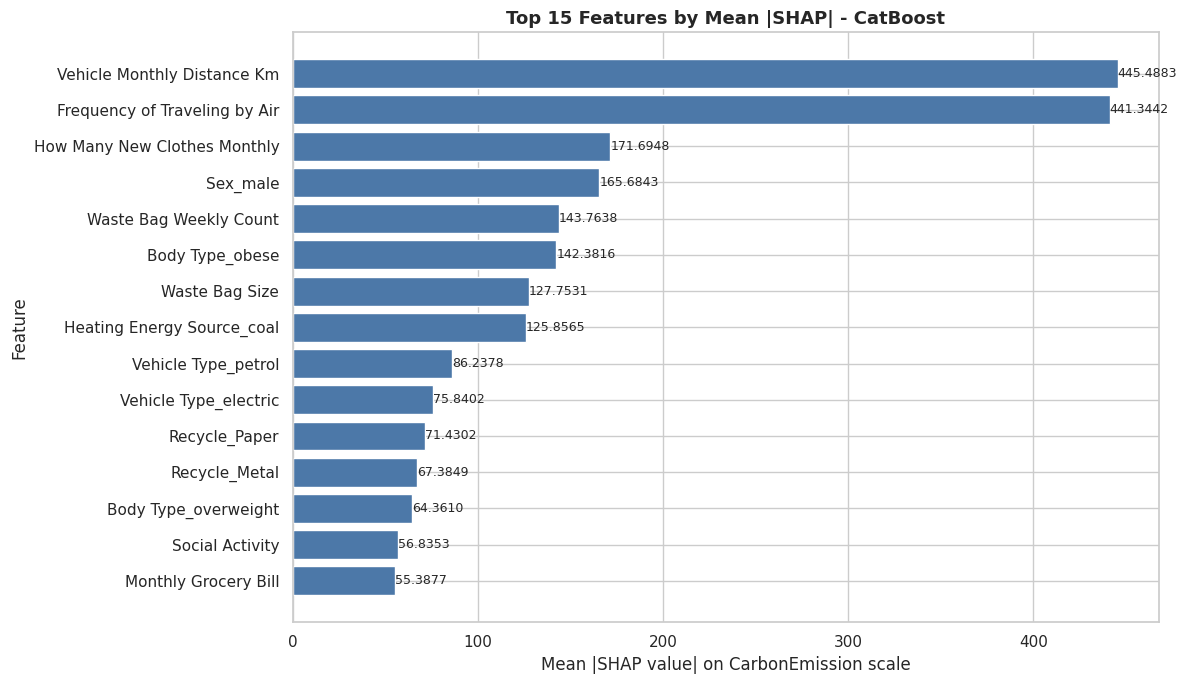

In [ ]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = (
    pd.DataFrame({"Feature": feature_names, "Mean_SHAP": mean_abs_shap})
    .sort_values("Mean_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_df.head(20))

fig, ax = plt.subplots(figsize=(12, 7))
top15 = shap_importance_df.head(15)
bars = ax.barh(top15["Feature"][::-1], top15["Mean_SHAP"][::-1], color="#4C78A8", edgecolor="white")
for bar, val in zip(bars, top15["Mean_SHAP"][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", fontsize=9)
ax.set_title(f"Top 15 Features by Mean |SHAP| - {best_tree_model_name}")
ax.set_xlabel("Mean |SHAP value| on CarbonEmission scale")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "shap_global_bar_custom.png", dpi=300, bbox_inches="tight")
plt.show()

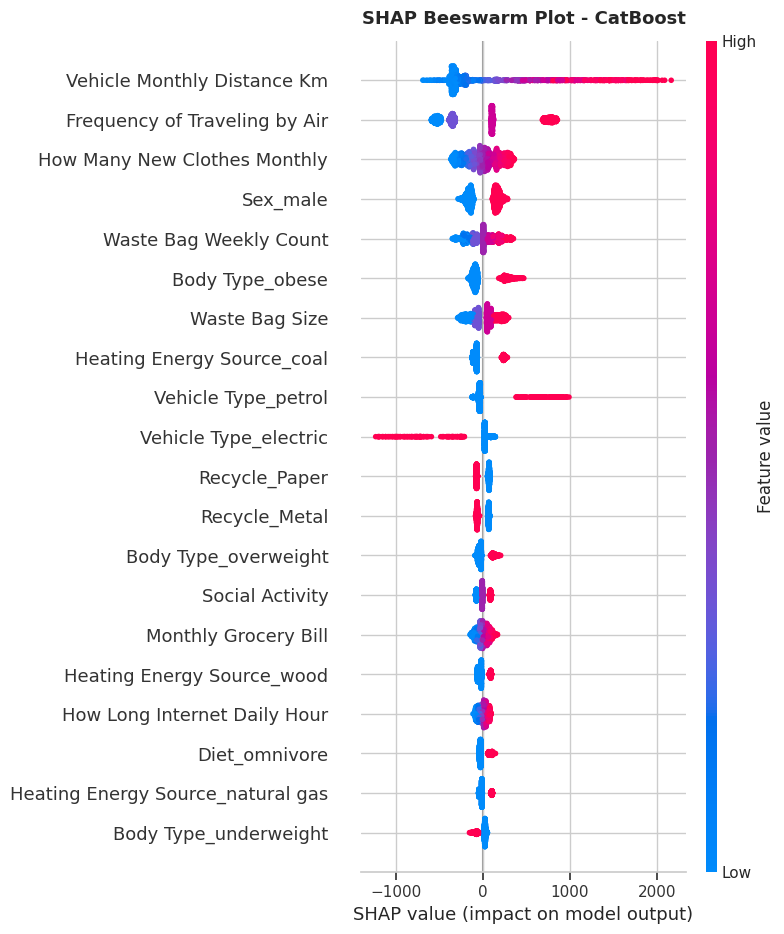

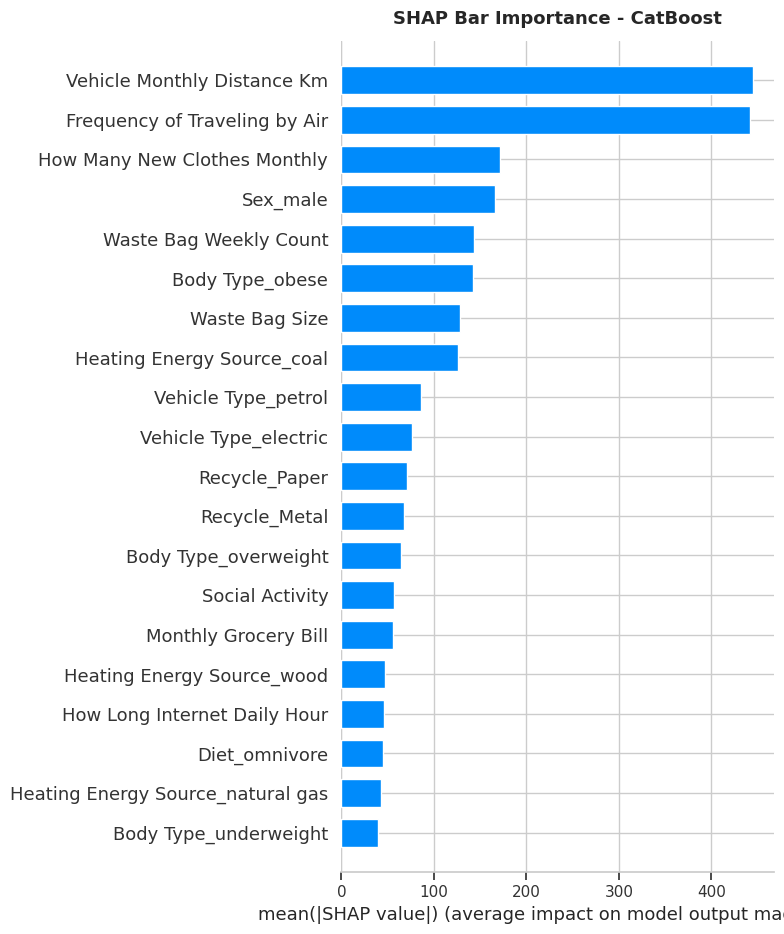

In [ ]:
shap.summary_plot(shap_values, X_for_shap_df, feature_names=feature_names, max_display=20, show=False)
plt.title(f"SHAP Beeswarm Plot - {best_tree_model_name}", pad=12)
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

shap.summary_plot(shap_values, X_for_shap_df, feature_names=feature_names, plot_type="bar", max_display=20, show=False)
plt.title(f"SHAP Bar Importance - {best_tree_model_name}", pad=12)
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "shap_bar_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Local Explanations: High, Median, and Low Emitters

Waterfall plots explain individual predictions by showing which features push a user's predicted emission up or down from the model baseline.

Highest emitter (idx=647): actual=6176 kg, predicted=6737 kg
Median emitter (idx=1171): actual=2005 kg, predicted=2108 kg
Lowest emitter (idx=1215): actual=460 kg, predicted=431 kg


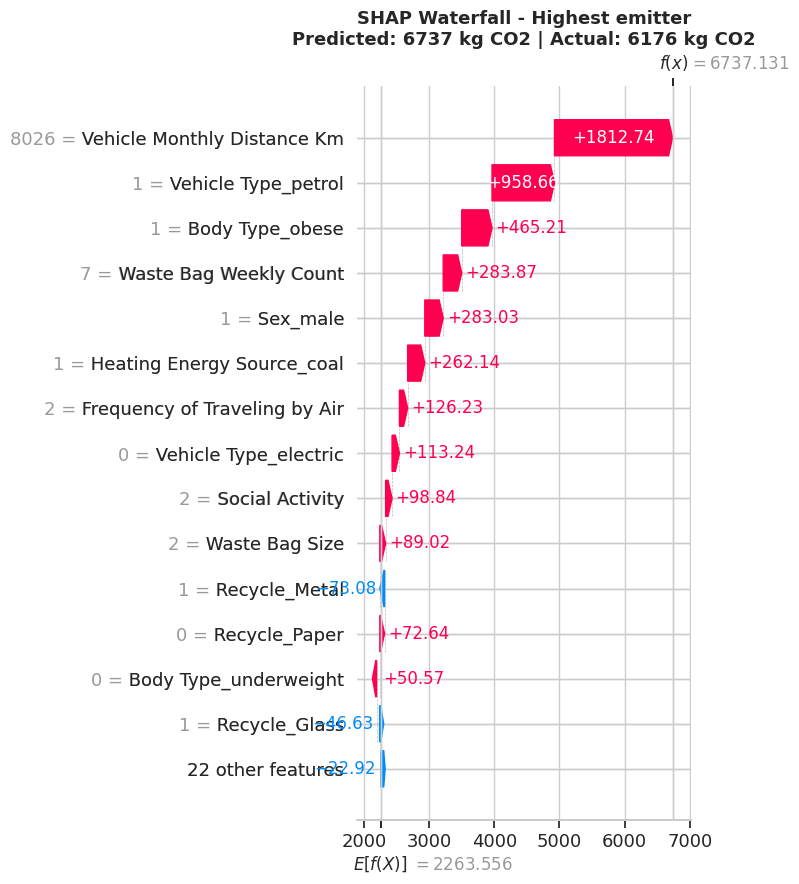

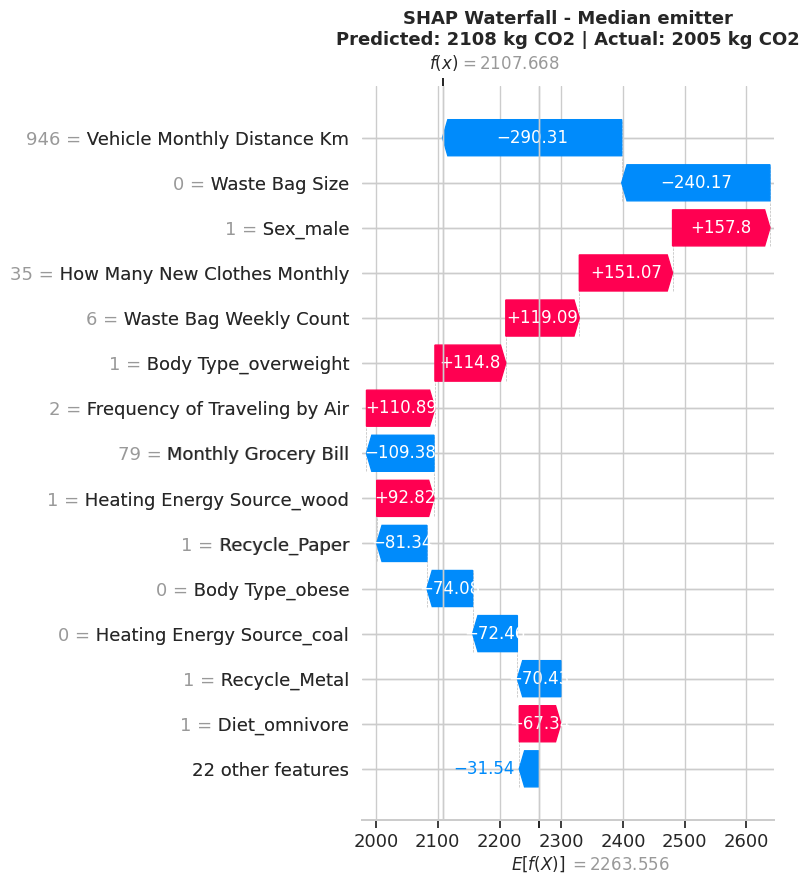

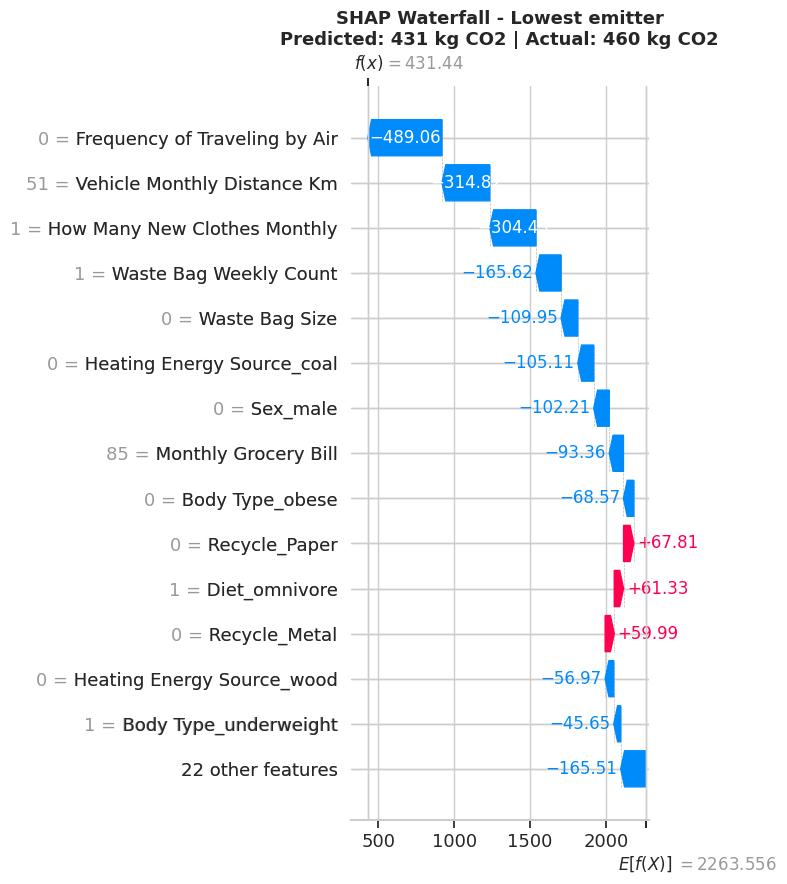

In [ ]:
preds_test = best_tree_model.predict(X_for_shap)
idx_highest = int(np.argmax(preds_test))
idx_lowest = int(np.argmin(preds_test))
idx_median = int(np.argsort(preds_test)[len(preds_test) // 2])

user_cases = {
    "Highest emitter": idx_highest,
    "Median emitter": idx_median,
    "Lowest emitter": idx_lowest,
}

for label, idx in user_cases.items():
    print(f"{label} (idx={idx}): actual={y_test_orig[idx]:.0f} kg, predicted={preds_test[idx]:.0f} kg")

for label, idx in user_cases.items():
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=expected_value,
            data=X_for_shap[idx],
            feature_names=feature_names,
        ),
        max_display=15,
        show=False,
    )
    plt.title(f"SHAP Waterfall - {label}\nPredicted: {preds_test[idx]:.0f} kg CO2 | Actual: {y_test_orig[idx]:.0f} kg CO2")
    plt.tight_layout()
    filename = "shap_waterfall_" + label.lower().replace(" ", "_") + ".png"
    plt.savefig(EXPLAIN_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

## 6. SHAP Dependence Plots

Dependence plots show how the actual value of a feature relates to its SHAP impact. These are useful for interpreting direction, thresholds, and interactions.

Top 4 features: ['Vehicle Monthly Distance Km', 'Frequency of Traveling by Air', 'How Many New Clothes Monthly', 'Sex_male']


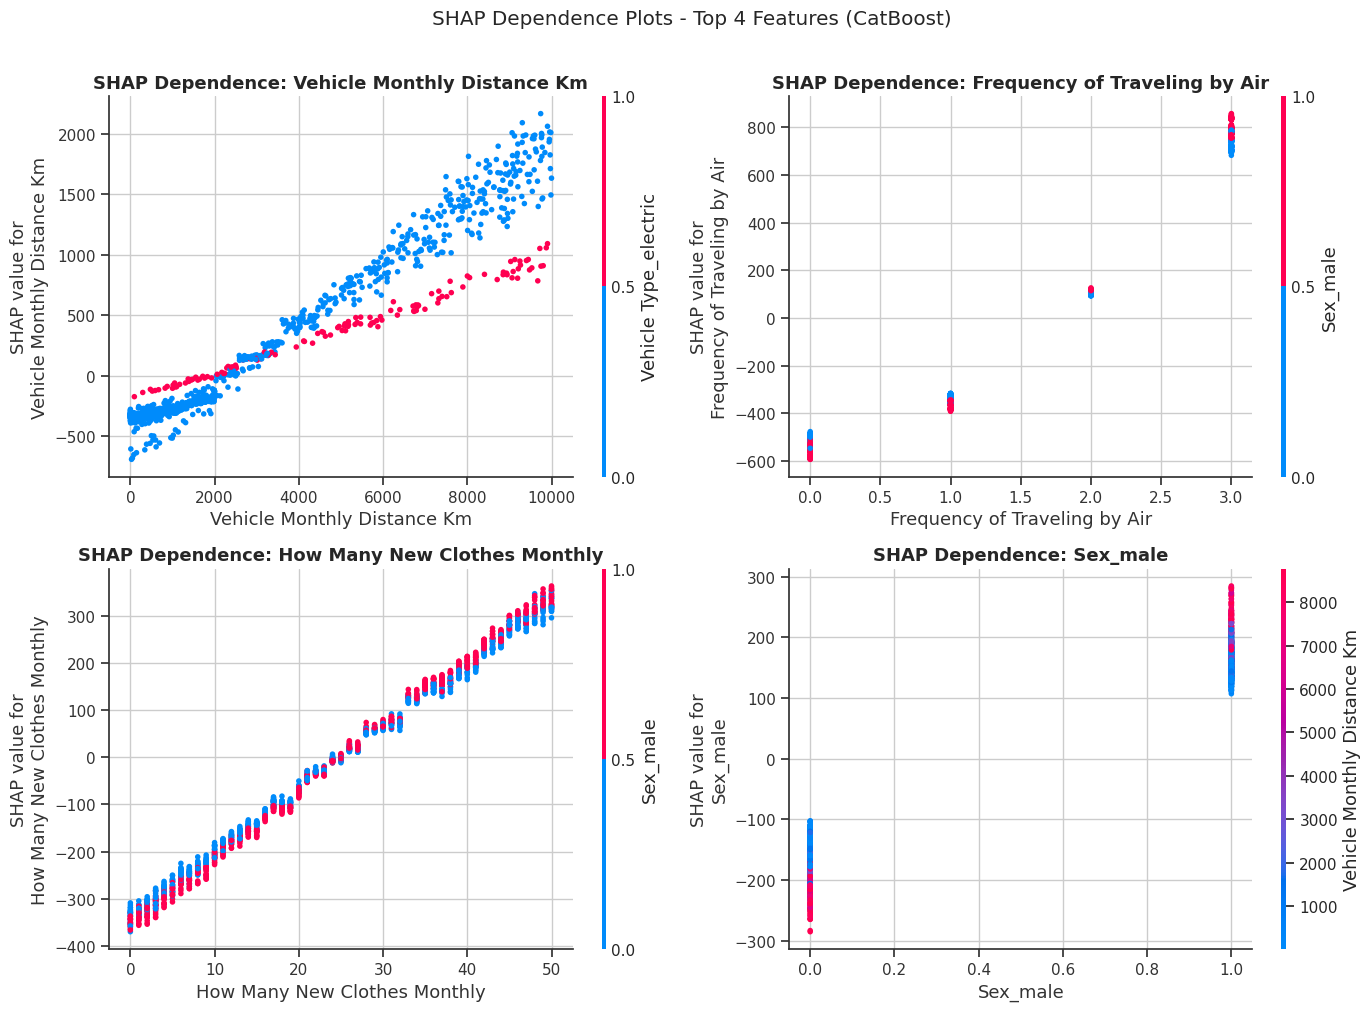

In [ ]:
top4_features = shap_importance_df["Feature"].head(4).tolist()
print("Top 4 features:", top4_features)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for i, feat in enumerate(top4_features):
    shap.dependence_plot(
        feat,
        shap_values,
        X_for_shap,
        feature_names=feature_names,
        ax=axes[i],
        show=False,
    )
    axes[i].set_title(f"SHAP Dependence: {feat}")
plt.suptitle(f"SHAP Dependence Plots - Top 4 Features ({best_tree_model_name})", y=1.01)
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "shap_dependence_top4.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Interactive SHAP Force Plots

Force plots are useful in notebooks and dashboards. They show feature-level push/pull effects for one user.

In [ ]:
print(f"Force plot · Highest emitter  idx={idx_highest}  "
      f"predicted={preds_test[idx_highest]:.0f} kg CO2")

# matplotlib=True renders as a static figure (no JS/initjs() warning).
shap.force_plot(
    expected_value,
    shap_values[idx_highest],
    X_for_shap[idx_highest],
    feature_names=feature_names,
    matplotlib=True,
    show=False,
)
plt.title(f"SHAP Force Plot — Highest Emitter ({preds_test[idx_highest]:.0f} kg CO2)",
          pad=14)
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "shap_force_highest.png", dpi=150, bbox_inches="tight")
plt.show()


Force plot for highest emitter, idx=647, predicted=6737 kg CO2


In [ ]:
print(f"Force plot · Lowest emitter  idx={idx_lowest}  "
      f"predicted={preds_test[idx_lowest]:.0f} kg CO2")

shap.force_plot(
    expected_value,
    shap_values[idx_lowest],
    X_for_shap[idx_lowest],
    feature_names=feature_names,
    matplotlib=True,
    show=False,
)
plt.title(f"SHAP Force Plot — Lowest Emitter ({preds_test[idx_lowest]:.0f} kg CO2)",
          pad=14)
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "shap_force_lowest.png", dpi=150, bbox_inches="tight")
plt.show()


Force plot for lowest emitter, idx=1215, predicted=431 kg CO2


## 8. Cross-Model SHAP Comparison

This compares normalized SHAP importance across all available models. Features that rank highly across models are more robust predictors.

In [ ]:
SAMPLE_SIZE = min(500, len(X_test))
sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(X_test), SAMPLE_SIZE, replace=False)
X_sample = X_test[sample_idx]
X_sample_s = X_test_s[sample_idx]

cross_model_importance = {}
for name, model in all_models.items():
    X_samp = X_sample_s if name == "Ridge Regression" else X_sample
    X_background = X_train_s if name == "Ridge Regression" else X_train
    try:
        if name == "Ridge Regression":
            exp = shap.LinearExplainer(model, X_background)
            sv = normalize_shap_values(exp.shap_values(X_samp))
        else:
            exp = shap.TreeExplainer(model)
            sv = normalize_shap_values(exp.shap_values(X_samp))
        mean_abs = np.abs(sv).mean(axis=0)
        mean_abs = mean_abs / (mean_abs.sum() + 1e-12)
        cross_model_importance[name] = mean_abs
        print(f"{name}: done")
    except Exception as exc:
        print(f"{name}: skipped ({exc})")

comp_df = pd.DataFrame(cross_model_importance, index=feature_names)
comp_df["Mean_across_models"] = comp_df.mean(axis=1)
comp_df = comp_df.sort_values("Mean_across_models", ascending=False)
display(comp_df.head(15).round(5))

Ridge Regression: done
Random Forest: done
XGBoost: done
LightGBM: done
CatBoost: done


,Ridge Regression,Random Forest,XGBoost,LightGBM,CatBoost,Mean_across_models
Vehicle Monthly Distance Km,0.15114,0.22341,0.16654,0.16363,0.16712,0.17437
Frequency of Traveling by Air,0.14011,0.21328,0.15698,0.15949,0.15926,0.16582
How Many New Clothes Monthly,0.05600,0.07660,0.06279,0.06326,0.06334,0.06440
Sex_male,0.05420,0.05783,0.05980,0.05994,0.06024,0.05840
Waste Bag Weekly Count,0.04697,0.05366,0.05225,0.05316,0.05355,0.05192
Body Type_obese,0.05037,0.04780,0.05081,0.05041,0.05113,0.05010
Heating Energy Source_coal,0.05554,0.02944,0.04785,0.04660,0.04663,0.04521
Waste Bag Size,0.04200,0.04342,0.04630,0.04685,0.04747,0.04521
Vehicle Type_electric,0.04777,0.04800,0.03464,0.03453,0.02629,0.03825
Vehicle Type_petrol,0.02457,0.04093,0.02995,0.03161,0.03218,0.03185


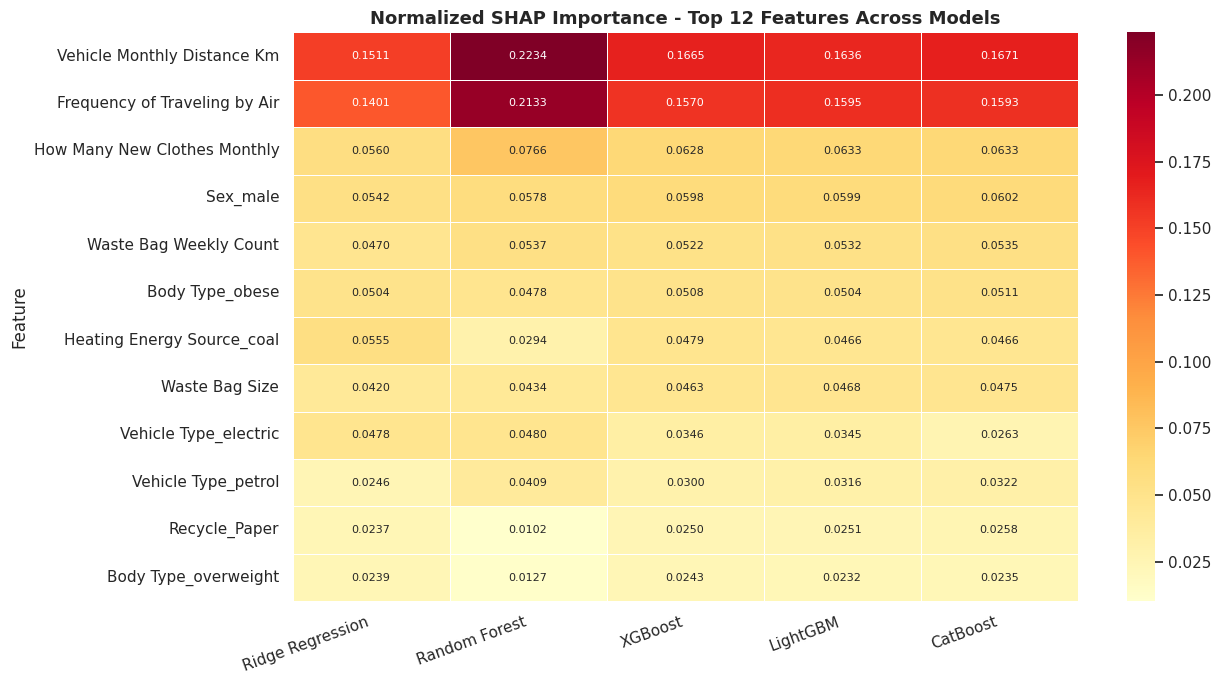

,Ridge Regression,Random Forest,XGBoost,LightGBM,CatBoost,Consistent_rank
Vehicle Monthly Distance Km,1,1,1,1,1,1.0
Frequency of Traveling by Air,2,2,2,2,2,2.0
How Many New Clothes Monthly,3,3,3,3,3,3.0
Sex_male,5,4,4,4,4,4.2
Waste Bag Weekly Count,8,5,5,5,5,5.6
Body Type_obese,6,7,6,6,6,6.2
Heating Energy Source_coal,4,10,7,8,8,7.4
Waste Bag Size,9,8,8,7,7,7.8
Vehicle Type_electric,7,6,9,9,10,8.2
Vehicle Type_petrol,12,9,10,10,9,10.0


In [ ]:
top12 = comp_df.head(12)
model_cols = [col for col in top12.columns if col != "Mean_across_models"]

plt.figure(figsize=(13, 7))
sns.heatmap(top12[model_cols], annot=True, fmt=".4f", cmap="YlOrRd", linewidths=0.5, annot_kws={"size": 8})
plt.title("Normalized SHAP Importance - Top 12 Features Across Models")
plt.ylabel("Feature")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "shap_cross_model_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

rank_df = comp_df[model_cols].rank(ascending=False).astype(int)
rank_df["Consistent_rank"] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values("Consistent_rank").head(15)
display(rank_df)

## 9. Permutation Importance

Permutation importance validates feature relevance by measuring performance loss when each feature is shuffled.

In [ ]:
print(f"Computing permutation importance for {best_tree_model_name}...")
perm_result = permutation_importance(
    best_tree_model,
    X_for_shap,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

perm_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Perm_Mean": perm_result.importances_mean,
        "Perm_Std": perm_result.importances_std,
    })
    .sort_values("Perm_Mean", ascending=False)
    .reset_index(drop=True)
)
perm_df["Perm_Mean_Positive"] = np.clip(perm_df["Perm_Mean"], 0, None)
perm_df["Perm_Norm"] = perm_df["Perm_Mean_Positive"] / (perm_df["Perm_Mean_Positive"].sum() + 1e-12)

display(perm_df.head(15))

Computing permutation importance for CatBoost...


,Feature,Perm_Mean,Perm_Std,Perm_Mean_Positive,Perm_Norm
0,Vehicle Monthly Distance Km,819.133697,12.687528,819.133697,0.231678
1,Frequency of Traveling by Air,631.134359,6.944138,631.134359,0.178505
2,Vehicle Type_electric,271.572568,7.249861,271.572568,0.076810
3,How Many New Clothes Monthly,209.595578,3.248362,209.595578,0.059281
4,Body Type_obese,182.422856,4.390200,182.422856,0.051595
5,Waste Bag Weekly Count,180.054499,3.107005,180.054499,0.050925
6,Sex_male,179.220745,2.241886,179.220745,0.050690
7,Vehicle Type_petrol,171.411398,4.530324,171.411398,0.048481
8,Waste Bag Size,152.240890,2.824948,152.240890,0.043059
9,Heating Energy Source_coal,145.527049,3.187684,145.527049,0.041160


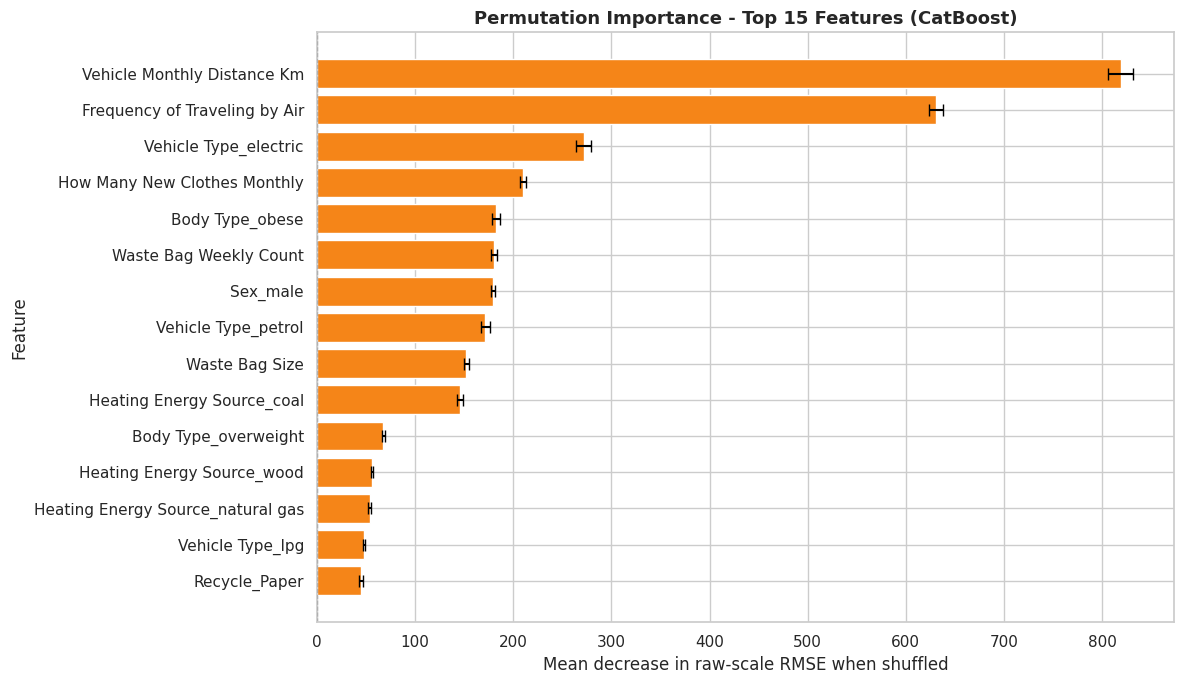

In [ ]:
top15_perm = perm_df.head(15)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(
    top15_perm["Feature"][::-1],
    top15_perm["Perm_Mean"][::-1],
    xerr=top15_perm["Perm_Std"][::-1],
    color="#F58518",
    edgecolor="white",
    capsize=4,
)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"Permutation Importance - Top 15 Features ({best_tree_model_name})")
ax.set_xlabel("Mean decrease in raw-scale RMSE when shuffled")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
print("Computing permutation importance for all available models on sample...")
all_perm = {}
for name, model in all_models.items():
    X_p = X_sample_s if name == "Ridge Regression" else X_sample
    y_p = y_test[sample_idx]
    pr = permutation_importance(
        model,
        X_p,
        y_p,
        n_repeats=5,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        scoring="neg_root_mean_squared_error",
    )
    vals = np.clip(pr.importances_mean, 0, None)
    vals = vals / (vals.sum() + 1e-12)
    all_perm[name] = vals
    print(f"{name}: done")

perm_all_df = pd.DataFrame(all_perm, index=feature_names)
perm_all_df["Mean_across_models"] = perm_all_df.mean(axis=1)
perm_all_df = perm_all_df.sort_values("Mean_across_models", ascending=False)
display(perm_all_df.head(15).round(5))

Computing permutation importance for all available models on sample...
Ridge Regression: done
Random Forest: done
XGBoost: done
LightGBM: done
CatBoost: done


,Ridge Regression,Random Forest,XGBoost,LightGBM,CatBoost,Mean_across_models
Vehicle Monthly Distance Km,0.26491,0.36237,0.24958,0.24398,0.23826,0.27182
Frequency of Traveling by Air,0.20854,0.24311,0.17775,0.17996,0.17442,0.19676
Vehicle Type_electric,0.07534,0.08159,0.08158,0.07911,0.07789,0.07910
How Many New Clothes Monthly,0.05759,0.05403,0.05959,0.05965,0.06022,0.05822
Vehicle Type_petrol,0.06236,0.04504,0.04938,0.05498,0.05116,0.05258
Sex_male,0.04527,0.03995,0.04890,0.05044,0.05075,0.04706
Body Type_obese,0.04455,0.03532,0.05188,0.05084,0.05181,0.04688
Waste Bag Weekly Count,0.04318,0.03501,0.05204,0.05126,0.05272,0.04684
Heating Energy Source_coal,0.04807,0.01414,0.04254,0.04126,0.04022,0.03725
Waste Bag Size,0.03205,0.02427,0.04192,0.04151,0.04308,0.03657


## 10. SHAP vs Permutation Agreement

If SHAP and permutation agree, the feature is a stronger candidate for the paper's final explanatory narrative.

In [ ]:
shap_rank = (
    pd.DataFrame({"Feature": feature_names, "SHAP_importance": mean_abs_shap})
    .sort_values("SHAP_importance", ascending=False)
    .reset_index(drop=True)
)
shap_rank["SHAP_rank"] = shap_rank.index + 1

perm_rank = perm_df[["Feature"]].copy()
perm_rank["Perm_rank"] = perm_rank.index + 1

comparison = shap_rank.merge(perm_rank, on="Feature")
comparison["Rank_diff"] = (comparison["SHAP_rank"] - comparison["Perm_rank"]).abs()
comparison["Agreement"] = comparison["Rank_diff"].apply(lambda x: "Strong" if x <= 2 else ("Moderate" if x <= 5 else "Weak"))

display(comparison.head(20)[["Feature", "SHAP_rank", "Perm_rank", "Rank_diff", "Agreement"]])

,Feature,SHAP_rank,Perm_rank,Rank_diff,Agreement
0,Vehicle Monthly Distance Km,1,1,0,Strong
1,Frequency of Traveling by Air,2,2,0,Strong
2,How Many New Clothes Monthly,3,4,1,Strong
3,Sex_male,4,7,3,Moderate
4,Waste Bag Weekly Count,5,6,1,Strong
5,Body Type_obese,6,5,1,Strong
6,Waste Bag Size,7,9,2,Strong
7,Heating Energy Source_coal,8,10,2,Strong
8,Vehicle Type_petrol,9,8,1,Strong
9,Vehicle Type_electric,10,3,7,Weak


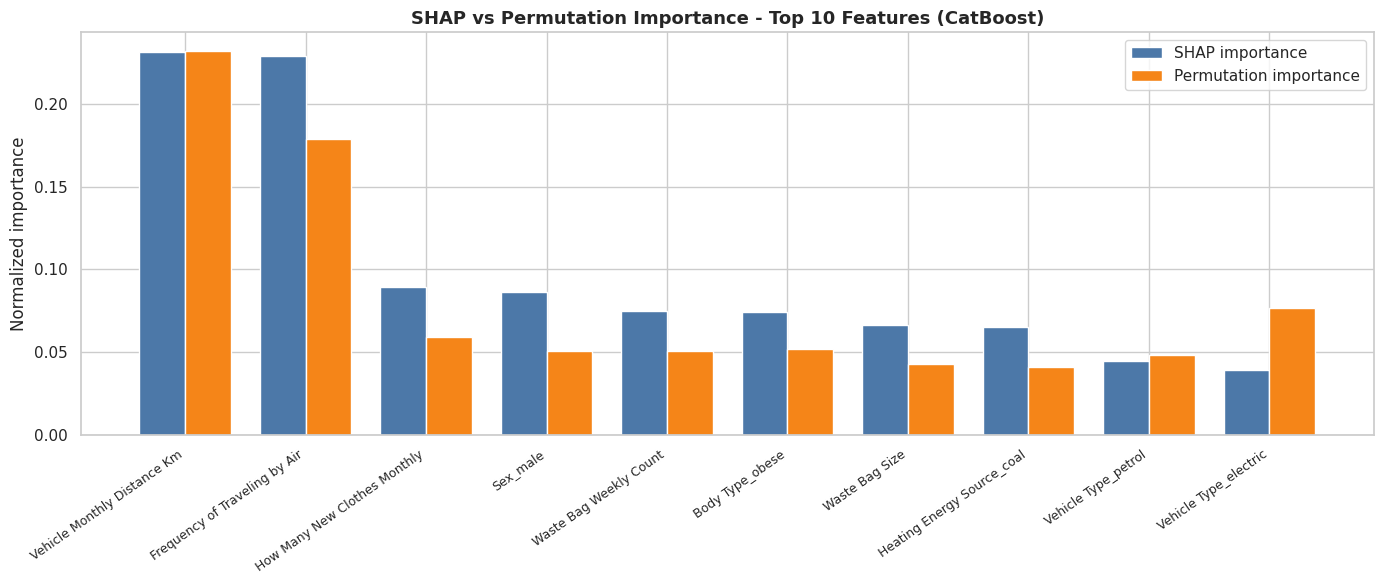

In [ ]:
top10 = comparison.head(10)
x = np.arange(len(top10))
width = 0.38
shap_norm = top10["SHAP_importance"] / (top10["SHAP_importance"].sum() + 1e-12)
perm_vals = perm_df.set_index("Feature").loc[top10["Feature"], "Perm_Norm"].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width / 2, shap_norm, width, label="SHAP importance", color="#4C78A8", edgecolor="white")
ax.bar(x + width / 2, perm_vals, width, label="Permutation importance", color="#F58518", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(top10["Feature"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Normalized importance")
ax.set_title(f"SHAP vs Permutation Importance - Top 10 Features ({best_tree_model_name})")
ax.legend()
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "shap_vs_permutation.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. SHAP-Based Feature Pruning

Keep features whose mean absolute SHAP value is above 1 percent of the maximum importance.

In [ ]:
threshold = shap_importance_df["Mean_SHAP"].max() * 0.01
keep_features = shap_importance_df[shap_importance_df["Mean_SHAP"] > threshold]["Feature"].tolist()
dropped_features = shap_importance_df[shap_importance_df["Mean_SHAP"] <= threshold]["Feature"].tolist()

print(f"Keeping {len(keep_features)} of {len(feature_names)} features")
print(f"Dropping {len(dropped_features)} low-SHAP features")
display(pd.DataFrame({"Dropped_Feature": dropped_features}))

# ── Validate the pruned feature set: retrain and compare ────────────────
# keep_features was only ever a diagnostic (SHAP importance > 1% of max)
# until this step. Retraining the same model type on just those features
# and comparing test-set metrics against the full-feature model turns it
# into an actual leaner model, backed by numbers rather than an unused
# JSON artifact.
keep_idx = [feature_names.index(f) for f in keep_features]
X_train_kept = X_tree_train[:, keep_idx]
X_test_kept  = X_tree_test[:, keep_idx]

shap_pruned_model = clone(best_tree_model)
shap_pruned_model.fit(X_train_kept, y_train)
pruned_preds = shap_pruned_model.predict(X_test_kept)

full_preds = best_tree_model.predict(X_tree_test)

def _metrics(y_true, y_pred):
    return {
        "MAE":  float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2":   float(r2_score(y_true, y_pred)),
        "MAPE": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
    }

full_metrics_shap   = _metrics(y_test_orig, full_preds)
pruned_metrics_shap = _metrics(y_test_orig, pruned_preds)

shap_pruning_compare_df = pd.DataFrame(
    [full_metrics_shap, pruned_metrics_shap],
    index=[
        f"{best_tree_model_name} (all {len(feature_names)} features)",
        f"{best_tree_model_name} (SHAP-pruned, {len(keep_features)} features)",
    ],
).round(4)

print(f"\nRetrained {best_tree_model_name} on the {len(keep_features)} SHAP-surviving "
      f"features (dropped {len(dropped_features)} of {len(feature_names)}):")
display(shap_pruning_compare_df)

r2_drop = full_metrics_shap["R2"] - pruned_metrics_shap["R2"]
print(f"R2 change from pruning: {-r2_drop:+.4f} "
      f"({'negligible' if abs(r2_drop) < 0.005 else 'noticeable'} — "
      f"{'the leaner model retains essentially all predictive power' if abs(r2_drop) < 0.005 else 'pruning traded some accuracy for a smaller feature set'})")

joblib.dump(shap_pruned_model, MODELS_DIR / "shap_pruned_model.joblib")
print("Saved leaner model to:", MODELS_DIR / "shap_pruned_model.joblib")


Keeping 35 of 36 features
Dropping 1 low-SHAP features


,Dropped_Feature
0,Transport_walk/bicycle


## 12. Lifestyle Archetype Clustering

KMeans identifies user lifestyle archetypes. Labels are derived directly from each cluster's actual emission level and feature averages (not hand-picked), so they stay accurate even as upstream feature selection changes. The fitted KMeans model is saved to disk so new users can be assigned an archetype without refitting.

,k,inertia,silhouette
0,2,1.032504e+10,0.790632
1,3,5.172708e+09,0.728782
2,4,2.597192e+09,0.672379
3,5,1.561110e+09,0.678009
4,6,1.110372e+09,0.675599
5,7,8.157290e+08,0.643089
6,8,6.121873e+08,0.642589


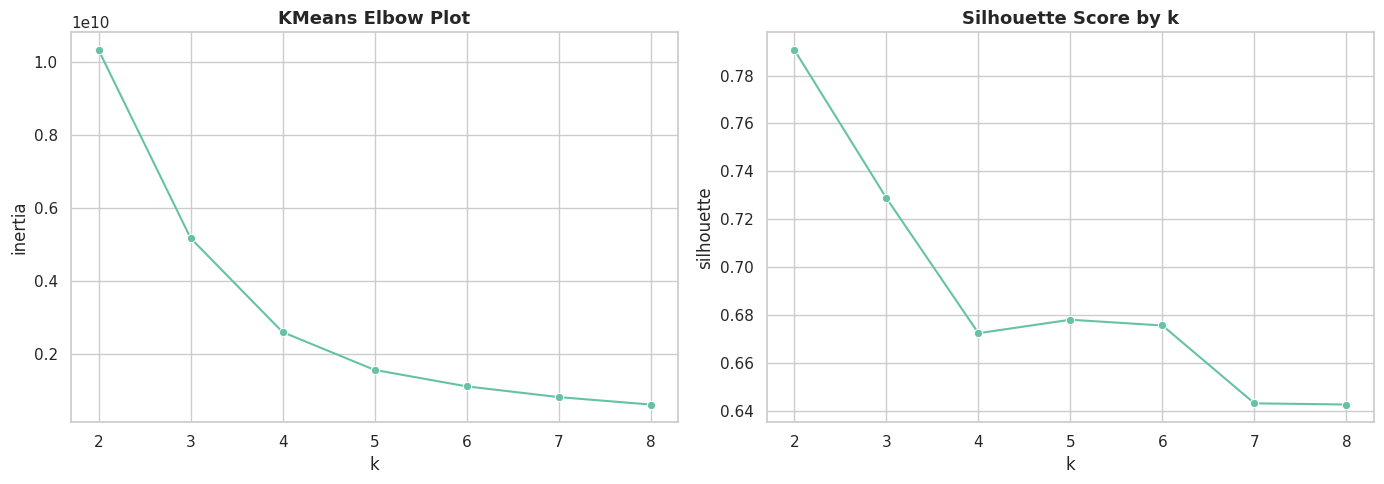

In [ ]:
inertias = []
silhouettes = []
k_values = range(2, 9)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_train_s)  # scaled — KMeans is distance-based, unscaled raw features (e.g. Vehicle Monthly Distance Km in the thousands) would dominate binary/ordinal ones
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_s, labels))

cluster_eval_df = pd.DataFrame({"k": list(k_values), "inertia": inertias, "silhouette": silhouettes})
display(cluster_eval_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=cluster_eval_df, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("KMeans Elbow Plot")
sns.lineplot(data=cluster_eval_df, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score by k")
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "kmeans_elbow_silhouette.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Choose k automatically: pick the k with the highest silhouette score
# from the evaluation computed in the cell above.
# Ties broken by preferring smaller k (simpler model).
best_k = int(cluster_eval_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
print(f"Auto-selected k={best_k} based on highest silhouette score ")
print(cluster_eval_df.to_string(index=False))
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
train_clusters = km_final.fit_predict(X_train_s)  # scaled, for the same reason as the elbow search above
test_clusters = km_final.predict(X_test_s)

# Save the fitted KMeans model so the web app can assign archetypes to new users
# without refitting (cluster assignments must stay stable across sessions).
joblib.dump(km_final, EXPLAIN_DIR / "kmeans_archetype_model.joblib")
print("Saved KMeans model to:", EXPLAIN_DIR / "kmeans_archetype_model.joblib")

cluster_profile = X_train_df.copy()
cluster_profile["cluster"] = train_clusters
cluster_profile["CarbonEmission"] = y_train_orig

# --- Data-driven archetype naming ---------------------------------------
# Instead of hand-picked labels, derive each archetype from the cluster's
# actual standing on emission level and on whichever signal features survived
# pruning (transport mode, air travel, heating, recycling, etc. — whatever
# exists in this run's feature set). This keeps the names accurate even if
# upstream feature selection changes which columns are present.
numeric_cols = cluster_profile.select_dtypes(include="number").columns.tolist()
signal_cols = [c for c in numeric_cols if c not in ["cluster", "CarbonEmission"]]

cluster_means = cluster_profile.groupby("cluster")[["CarbonEmission"] + signal_cols].mean()
overall_emission_mean = cluster_profile["CarbonEmission"].mean()

# Candidate signal features for narrative labeling, used only if present.
# NOTE: "Transport" was one-hot encoded with drop_first=True and "private" as the
# reference category (see Section 9), so a "Transport_private" column never exists.
# Private-transport users are instead identified by LOW signal on the remaining
# Transport_* dummies (e.g. Transport_public, Transport_walk/bicycle).
transport_nonpriv_cols = [c for c in signal_cols if c.startswith("Transport_")]
air_travel_col = next((c for c in signal_cols if "Air" in c and "Frequency" in c), None)
heating_cols = [c for c in signal_cols if c.startswith("Heating Energy Source_")]
recycle_cols = [c for c in signal_cols if c.startswith("Recycle_")]
digital_cols = [c for c in signal_cols if "Internet" in c or "Screen" in c or "TV" in c.lower()]

def build_archetype_label(row):
    emission_tag = "High-Emission" if row["CarbonEmission"] >= overall_emission_mean else "Low-Emission"

    descriptors = []
    if air_travel_col and row[air_travel_col] >= cluster_means[air_travel_col].median():
        descriptors.append("Frequent Flyer")
    if transport_nonpriv_cols and row[transport_nonpriv_cols].mean() <= cluster_means[transport_nonpriv_cols].mean().mean():
        descriptors.append("Private-Transport")
    if heating_cols and row[heating_cols].sum() > 0:
        descriptors.append("Non-Electric-Heating")
    if recycle_cols and row[recycle_cols].mean() >= cluster_means[recycle_cols].mean().mean():
        descriptors.append("Recycler")
    if digital_cols and row[digital_cols].mean() >= cluster_means[digital_cols].mean().mean():
        descriptors.append("Digital-Heavy")

    if not descriptors:
        descriptors.append("General Lifestyle")

    # Use ALL descriptors (not just the first) for a richer label.
    # Building the joined string as a separate variable avoids the
    # Python < 3.12 restriction on literal quotes inside an f-string
    # expression, and ", " reads better than " + " in the final label.
    label_parts = ", ".join(descriptors)
    return f"{emission_tag} / {label_parts}"

archetype_names = {cluster_id: build_archetype_label(row) for cluster_id, row in cluster_means.iterrows()}

# Disambiguate duplicate labels (e.g. two clusters both landing on "High-Emission / Recycler")
seen = {}
for cluster_id, label in list(archetype_names.items()):
    seen[label] = seen.get(label, 0) + 1
    if seen[label] > 1:
        archetype_names[cluster_id] = f"{label} ({seen[label]})"

print("Data-driven archetype labels:")
for cluster_id, label in archetype_names.items():
    print(f"  Cluster {cluster_id}: {label}")

cluster_profile["archetype"] = cluster_profile["cluster"].map(archetype_names)

with open(EXPLAIN_DIR / "archetype_labels.json", "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in archetype_names.items()}, f, indent=2)

# Dynamically aggregate whatever numeric columns survived pruning
agg_cols = signal_cols

cluster_summary_full = (
    cluster_profile.groupby(["cluster", "archetype"])[["CarbonEmission"] + agg_cols]
    .agg(["mean", "median", "size"])
    .reset_index()
)
cluster_summary_full.columns = ["_".join(c).strip("_") for c in cluster_summary_full.columns]

# Clean summary with just the key emission stats
cluster_summary = cluster_summary_full[
    ["cluster", "archetype", "CarbonEmission_size", "CarbonEmission_mean", "CarbonEmission_median"]
].rename(columns={
    "CarbonEmission_size": "users",
    "CarbonEmission_mean": "mean_emission",
    "CarbonEmission_median": "median_emission",
})

# Append means of any ordinal features that exist
for col in ["Frequency of Traveling by Air", "Waste Bag Size", "How Often Shower",
            "Social Activity", "Energy efficiency"]:
    mean_col = f"{col}_mean"
    if mean_col in cluster_summary_full.columns:
        cluster_summary[col] = cluster_summary_full[mean_col].values

display(cluster_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=cluster_summary, x="archetype", y="mean_emission", color="#4C78A8")
plt.title("Mean Carbon Emission by Lifestyle Archetype")
plt.xlabel("Archetype")
plt.ylabel("Mean CarbonEmission")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(EXPLAIN_DIR / "cluster_mean_emission.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Stacking Ensemble

Combines the tuned tree models (Random Forest, XGBoost, LightGBM, CatBoost) as base learners with a `RidgeCV` meta-learner via `StackingRegressor`. `RidgeCV` picks its own regularization strength by internal cross-validation, which is a free improvement over a fixed-alpha `Ridge` meta-learner — there is no reason to leave that knob unpicked when it costs nothing extra. Out-of-fold predictions (cv=5) from each base learner feed into Ridge, which learns how to weight them.

**Note on scaling:** all base learners operate on raw unscaled features. The RidgeCV meta-learner receives the base learners' *predictions* as inputs — already on the same scale (kg CO₂) — so no additional scaling is needed. This differs from the stand-alone Ridge model, which requires scaled raw features.

In [ ]:
print("Training stacking ensemble (RF + XGBoost + LightGBM + CatBoost -> RidgeCV meta-learner)...")

_base_learner_keys = [
    ("rf", "Random Forest"),
    ("xgb", "XGBoost"),
    ("lgbm", "LightGBM"),
    ("cat", "CatBoost"),
]
base_learners = [(short, clone(all_models[key])) for short, key in _base_learner_keys if key in all_models]

if len(base_learners) < 2:
    raise ValueError("Need at least 2 tree models available to build a stacking ensemble.")

stacking_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=RidgeCV(alphas=np.logspace(-3, 4, 50)),
    cv=5,
    n_jobs=-1,
)
stacking_model.fit(X_train, y_train)
stacking_preds = stacking_model.predict(X_test)

stacking_metrics = {
    "MAE": float(mean_absolute_error(y_test_orig, stacking_preds)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test_orig, stacking_preds))),
    "R2": float(r2_score(y_test_orig, stacking_preds)),
    "MAPE": float(np.mean(np.abs((y_test_orig - stacking_preds) / y_test_orig)) * 100),
}

print("Stacking ensemble metrics (test set, raw CarbonEmission scale):")
for metric, value in stacking_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Compare against the single best tree model for context
best_single_preds = best_tree_model.predict(X_tree_test)
best_single_metrics = {
    "MAE": float(mean_absolute_error(y_test_orig, best_single_preds)),
    "RMSE": float(np.sqrt(mean_squared_error(y_test_orig, best_single_preds))),
    "R2": float(r2_score(y_test_orig, best_single_preds)),
    "MAPE": float(np.mean(np.abs((y_test_orig - best_single_preds) / y_test_orig)) * 100),
}

stacking_compare_df = pd.DataFrame(
    [best_single_metrics, stacking_metrics],
    index=[f"{best_tree_model_name} (single best)", "Stacking Ensemble"],
).round(4)
display(stacking_compare_df)

joblib.dump(stacking_model, MODELS_DIR / "stacking_ensemble.joblib")
print("Saved stacking ensemble to:", MODELS_DIR / "stacking_ensemble.joblib")

# ── Give the stacking ensemble a fair, CV-based comparison ──────────────
# Everything above is a single fit + single test-set score, which is
# exactly the kind of one-shot number we stopped relying on for the other
# five models (see the CV-based model-selection fix). cv_score() is the
# same 5-fold helper from Part 2's "Cross-Validation of Tuned Models"
# section, still available in this kernel session — reusing it here puts
# the stacking ensemble on equal footing with cv_summary_df instead of
# only ever being judged by one test split.
print("\nCross-validating stacking ensemble (5-fold, training data only, "
      "same protocol as the other five models)...")
stacking_cv_summary, _stacking_cv_folds = cv_score(clone(stacking_model), X_train, y_train, folds=CV_FOLDS)
print(f"  CV RMSE: {stacking_cv_summary['RMSE']['mean']:.4f} +/- {stacking_cv_summary['RMSE']['std']:.4f}")
print(f"  CV R2:   {stacking_cv_summary['R2']['mean']:.4f} +/- {stacking_cv_summary['R2']['std']:.4f}")

cv_compare_df = pd.concat([
    cv_summary_df[["Model", "CV_RMSE_mean", "CV_RMSE_std"]],
    pd.DataFrame([{
        "Model": "Stacking Ensemble",
        "CV_RMSE_mean": stacking_cv_summary["RMSE"]["mean"],
        "CV_RMSE_std": stacking_cv_summary["RMSE"]["std"],
    }]),
], ignore_index=True).sort_values("CV_RMSE_mean")

print("\nStacking ensemble vs. the five individual models — CV RMSE (leakage-safe, training data only):")
display(cv_compare_df)

overall_best_by_cv = cv_compare_df.iloc[0]["Model"]
print(f"Overall best model by CV RMSE (including the stacking ensemble): {overall_best_by_cv}")


## 14. Counterfactual Recommendations

This tests actionable changes one at a time and returns the top predicted emission reductions, run for all three reference profiles from Section 5 (highest, median, and lowest emitter) rather than the highest emitter alone.

In [ ]:
def predict_emission(model, row_2d):
    """Predict on raw scale."""
    return float(model.predict(row_2d)[0])


def build_action_catalogue(feature_names):
    """
    Build all testable what-if actions using the ACTUAL one-hot encoded
    column names that exist in the pruned feature set.

    Encoding conventions (drop_first=True reference categories):
      Transport     -> "private"     (all Transport_* = 0 means private car)
      Vehicle Type  -> "none"        (all Vehicle Type_* = 0 means no vehicle)
      Heating       -> "electricity" (all Heating_* = 0 = electric)
      Diet          -> "vegetarian"  (all Diet_* = 0 means vegetarian)

    IMPORTANT — dependent-feature consistency:
    "Vehicle Monthly Distance Km" is the single highest-importance feature
    in this model (by both SHAP and permutation importance), and it is
    logically dependent on whether the person uses a personal vehicle at
    all. Any action that drops personal-vehicle use (switching to public
    transport, walking/cycling, or giving up the vehicle entirely) must
    also zero out this feature — otherwise the perturbed row says "no
    vehicle" while still carrying a large vehicle-distance value, which
    is a combination the model never saw in training and which silently
    understates the true predicted impact of the action. Actions that
    keep driving but change *what* is driven (electric/hybrid vehicle)
    correctly leave this feature untouched.
    """
    fn = set(feature_names)
    actions = []
    distance_col = "Vehicle Monthly Distance Km" if "Vehicle Monthly Distance Km" in fn else None

    # -- AIR TRAVEL -------------------------------------------------------
    air_col = next((c for c in feature_names if c == "Frequency of Traveling by Air"), None)
    if air_col:
        actions.append(("Stop air travel entirely",   {air_col: 0}))
        actions.append(("Reduce air travel to rarely", {air_col: 1}))

    # -- TRANSPORT MODE ---------------------------------------------------
    transport_cols = [c for c in feature_names if c.startswith("Transport_")]
    if transport_cols:
        zero_t = {c: 0 for c in transport_cols}

        pub = dict(zero_t)
        if "Transport_public" in fn:
            pub["Transport_public"] = 1
        if distance_col:
            pub[distance_col] = 0  # no longer driving a personal vehicle
        actions.append(("Switch to public transport", pub))

        walk = dict(zero_t)
        if "Transport_walk/bicycle" in fn:
            walk["Transport_walk/bicycle"] = 1
        if distance_col:
            walk[distance_col] = 0  # no longer driving a personal vehicle
        actions.append(("Switch to walking / cycling", walk))

    # -- VEHICLE TYPE -----------------------------------------------------
    vehicle_cols = [c for c in feature_names if c.startswith("Vehicle Type_")]
    if vehicle_cols:
        zero_v = {c: 0 for c in vehicle_cols}

        # Electric/hybrid: still driving the same distance, just a
        # different vehicle type — distance_col is intentionally NOT
        # touched here.
        elec = dict(zero_v)
        if "Vehicle Type_electric" in fn:
            elec["Vehicle Type_electric"] = 1
        actions.append(("Switch to electric vehicle", elec))

        hybrid = dict(zero_v)
        if "Vehicle Type_hybrid" in fn:
            hybrid["Vehicle Type_hybrid"] = 1
        actions.append(("Switch to hybrid vehicle", hybrid))

        # Giving up the vehicle entirely: distance must drop too.
        give_up = dict(zero_v)
        if distance_col:
            give_up[distance_col] = 0
        actions.append(("Give up personal vehicle", give_up))

    # -- HEATING ----------------------------------------------------------
    heat_cols = [c for c in feature_names if c.startswith("Heating Energy Source_")]
    if heat_cols:
        actions.append(("Switch heating to electricity",
                         {c: 0 for c in heat_cols}))

    # -- DIET -------------------------------------------------------------
    diet_cols = [c for c in feature_names if c.startswith("Diet_")]
    if diet_cols:
        zero_d = {c: 0 for c in diet_cols}
        actions.append(("Switch to vegetarian diet", dict(zero_d)))

        vegan = dict(zero_d)
        if "Diet_vegan" in fn:
            vegan["Diet_vegan"] = 1
        actions.append(("Switch to vegan diet", vegan))

    # -- RECYCLING --------------------------------------------------------
    recycle_cols = [c for c in feature_names if c.startswith("Recycle_")]
    if recycle_cols:
        paper_plastic = {c: 1 for c in ["Recycle_Paper", "Recycle_Plastic"] if c in fn}
        if paper_plastic:
            actions.append(("Recycle paper and plastic", paper_plastic))
        actions.append(("Recycle all materials",
                         {c: 1 for c in recycle_cols}))

    return actions


def generate_whatif(user_row, model, feature_names, top_n=5, target_reduction=0.20):
    """
    For each actionable change, compute the predicted emission reduction.
    Returns the top_n most impactful actions as a DataFrame.
    """
    baseline  = predict_emission(model, user_row.reshape(1, -1))
    target    = baseline * (1 - target_reduction)
    catalogue = build_action_catalogue(feature_names)
    results   = []

    for label, changes in catalogue:
        relevant = {k: v for k, v in changes.items() if k in feature_names}
        if not relevant:
            continue

        modified = user_row.copy()
        for feat, val in relevant.items():
            modified[feature_names.index(feat)] = val

        new_emission = predict_emission(model, modified.reshape(1, -1))
        reduction    = baseline - new_emission

        if reduction > 0:
            results.append({
                "Action":            label,
                "Current (kg CO2)":  round(baseline, 0),
                "After Change (kg)": round(new_emission, 0),
                "Reduction (kg)":    round(reduction, 1),
                "Reduction (%)":     round(reduction / baseline * 100, 1),
                "20% Target Met":    "Yes" if new_emission <= target else "No",
            })

    return (
        pd.DataFrame(results)
        .sort_values("Reduction (kg)", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


# -- Run for all three reference profiles ---------------------------------
print("\n" + "=" * 65)
print("  WHAT-IF SCENARIO ANALYSIS -- TOP 5 EMISSION-REDUCTION ACTIONS")
print("=" * 65)

all_whatif = {}
for label, idx in user_cases.items():
    wf = generate_whatif(X_tree_test[idx], best_tree_model, feature_names, top_n=5)
    all_whatif[label] = wf
    print(f"\n-- {label}  (predicted = {preds_test[idx]:.0f} kg CO2) --")
    if not wf.empty:
        display(wf)
    else:
        print("  No actionable reductions found -- already near-minimum emissions.")

# Backwards-compatible alias used by later cells
counterfactuals = all_whatif.get("Highest emitter", pd.DataFrame()).to_dict("records")



=== Highest emitter (idx=647, predicted=6737 kg CO2) ===


,action,reduction_kg,new_emission,target_met
0,Change Frequency of Traveling by Air to 0,818.3,5918.8,False
1,Change Frequency of Traveling by Air to 1,576.8,6160.3,False
2,Switch diet profile to vegan,28.1,6709.0,False



=== Median emitter (idx=1171, predicted=2108 kg CO2) ===


,action,reduction_kg,new_emission,target_met
0,Change Frequency of Traveling by Air to 0,694.2,1413.4,True
1,Change Frequency of Traveling by Air to 1,497.8,1609.9,True
2,Switch diet profile to vegan,71.9,2035.7,False



=== Lowest emitter (idx=1215, predicted=431 kg CO2) ===


,action,reduction_kg,new_emission,target_met
0,Switch diet profile to vegan,54.3,377.1,False
1,Switch diet profile to vegetarian,38.2,393.3,False


## 15. Simple Prediction Interval

Uses out-of-fold residuals on the raw target scale to create a rough 90 percent interval around a prediction. The target was never log-transformed in this pipeline, so every quantity here — predictions, residuals, and the interval bounds — is already on the original `CarbonEmission` (kg CO2) scale.

In [ ]:
print("Computing out-of-fold predictions for adaptive prediction intervals (cv=5)...")
oof_preds_raw = cross_val_predict(
    clone(best_tree_model), X_tree_train, y_train, cv=5, n_jobs=-1
)
residuals_raw = np.abs(y_train - oof_preds_raw)

# ── Adaptive (quantile-binned) interval ─────────────────────────────────
# A global 90th-percentile residual gives every user the same ± width,
# which is too wide for low emitters and too narrow for high emitters.
# Instead, bin the OOF predictions into 5 quantile groups and compute
# a separate 90th-percentile residual for each bin. At inference time,
# look up which bin the new prediction falls in to get a calibrated interval.

N_BINS = 5
oof_series  = pd.Series(oof_preds_raw, name="pred")
# duplicates="drop" avoids a ValueError when many OOF predictions are tied
# (possible with this dataset); it can silently return fewer than N_BINS
# edges, so bin_labels is derived from the actual edges rather than N_BINS.
bin_edges   = pd.qcut(oof_series, q=N_BINS, retbins=True, duplicates="drop")[1]
bin_labels  = list(range(len(bin_edges) - 1))

oof_df = pd.DataFrame({"pred": oof_preds_raw, "residual": residuals_raw})
oof_df["bin"] = pd.cut(oof_df["pred"], bins=bin_edges, labels=bin_labels,
                        include_lowest=True).astype(int)
bin_quantiles = (
    oof_df.groupby("bin")["residual"]
    .quantile(0.90)
    .rename("interval_90")
)
print("Per-bin 90th-percentile residuals (adaptive intervals):")
print(bin_quantiles.to_frame().assign(
    pred_range_lo=bin_edges[:-1].round(0),
    pred_range_hi=bin_edges[1:].round(0),
).to_string())

def adaptive_interval(prediction, bin_edges, bin_quantiles):
    """Return (lower, upper) 90% prediction interval for a given prediction."""
    bin_idx = int(np.searchsorted(bin_edges[1:-1], prediction))
    bin_idx = max(0, min(bin_idx, len(bin_quantiles) - 1))
    half_width = bin_quantiles.iloc[bin_idx]
    return max(0, prediction - half_width), prediction + half_width

# ── Show intervals for all three reference users ─────────────────────────
print()
for label, idx in user_cases.items():
    row      = X_tree_test[[idx]]
    pred_val = float(best_tree_model.predict(row)[0])
    lo, hi   = adaptive_interval(pred_val, bin_edges, bin_quantiles)
    print(f"{label:25s}  predicted={pred_val:6.0f} kg   "
          f"90% interval=[{lo:5.0f}, {hi:6.0f}]")


Predicted: 992 kg CO2
90% interval: [850, 1133]


## 16. Save Outputs

Saves figures, tables, SHAP arrays, and a compact JSON summary into `outputs/explainability/`.

In [ ]:
shap_importance_df.to_csv(EXPLAIN_DIR / "shap_importance.csv", index=False)
comp_df.round(6).to_csv(EXPLAIN_DIR / "shap_cross_model.csv")
perm_df.to_csv(EXPLAIN_DIR / "permutation_importance.csv", index=False)
perm_all_df.round(6).to_csv(EXPLAIN_DIR / "permutation_importance_all_models.csv")
comparison.to_csv(EXPLAIN_DIR / "shap_vs_permutation.csv", index=False)
cluster_eval_df.to_csv(EXPLAIN_DIR / "cluster_k_evaluation.csv", index=False)
cluster_summary.to_csv(EXPLAIN_DIR / "cluster_archetype_summary.csv", index=False)
np.save(EXPLAIN_DIR / "shap_values_test.npy", shap_values)

with open(EXPLAIN_DIR / "keep_features.json", "w", encoding="utf-8") as f:
    json.dump(keep_features, f, indent=2)

summary = {
    "best_overall_model": best_model_name,
    "best_tree_model_for_shap": best_tree_model_name,
    "kept_feature_count": int(len(keep_features)),
    "total_feature_count": int(len(feature_names)),
    "shap_pruned_model_path": str(MODELS_DIR / "shap_pruned_model.joblib"),
    "shap_pruning_comparison": {
        "full_model": full_metrics_shap,
        "pruned_model": pruned_metrics_shap,
    },
    "cluster_count": int(best_k),
    "archetype_labels": {str(k): v for k, v in archetype_names.items()},
    "kmeans_model_path": str(EXPLAIN_DIR / "kmeans_archetype_model.joblib"),
    "stacking_metrics": {k: float(v) for k, v in stacking_metrics.items()},
    "stacking_cv_rmse_mean": float(stacking_cv_summary["RMSE"]["mean"]),
    "stacking_cv_rmse_std": float(stacking_cv_summary["RMSE"]["std"]),
    "overall_best_by_cv_including_stacking": str(overall_best_by_cv),
}
with open(EXPLAIN_DIR / "explainability_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved explainability outputs to:", EXPLAIN_DIR)
for path in sorted(EXPLAIN_DIR.iterdir()):
    print("-", path.name)

Saved explainability outputs to: outputs/explainability
- archetype_labels.json
- cluster_archetype_summary.csv
- cluster_k_evaluation.csv
- cluster_mean_emission.png
- explainability_summary.json
- keep_features.json
- kmeans_archetype_model.joblib
- kmeans_elbow_silhouette.png
- permutation_importance.csv
- permutation_importance.png
- permutation_importance_all_models.csv
- shap_bar_importance.png
- shap_beeswarm.png
- shap_cross_model.csv
- shap_cross_model_heatmap.png
- shap_dependence_top4.png
- shap_global_bar_custom.png
- shap_importance.csv
- shap_values_test.npy
- shap_vs_permutation.csv
- shap_vs_permutation.png
- shap_waterfall_highest_emitter.png
- shap_waterfall_lowest_emitter.png
- shap_waterfall_median_emitter.png
- stacking_regressor.joblib
